# Phase 2: DINOv3 ViT Deepfake Detection Training on Domain-Balanced Dataset

## Overview & Key Objectives
This notebook executes the end-to-end training, validation, and multi-faceted evaluation pipeline of a **Vision Transformer (ViT-Small/16)** initialized with self-supervised **DINOv3** weights (`dinov3-vits16plus-pretrain-lvd1689m`).

### Key Components:
1. **Cross-Domain Balanced Dataset Protocol:** Combines 25,000 Real faces (Celeb-DF + FF++) and 25,000 Deepfake faces (Celeb-synthesis + DF40 across 40 manipulation methods), eliminating dataset shortcut learning.
2. **Domain-Agnostic Augmentation Pipeline:** `ColorJitter`, `GaussianBlur`, `RandomAdjustSharpness`, and `RandomErasing (Face Cutout)` to force attention onto anatomical manipulation artifacts rather than compression or domain noise.
3. **EXP-01 LLRD Optimization:** Layer-wise Learning Rate Decay ($\gamma = 0.80$) with Label Smoothing Cross-Entropy Loss ($\epsilon = 0.05$).
4. **Comprehensive Evaluation Suite:** Evaluates on held-out `test_balanced.csv` (4,134 images, exact 1:1 balance) with Per-Method Breakdown across 40 generators, Error Analysis Gallery, and Multi-Head Self-Attention visual heatmaps.

## 1. Environment Setup, Hardware Verification & Deterministic Seeding

We configure the environment, enforce strict deterministic seeds across PyTorch, NumPy, and Python standard libraries, and verify GPU compute capabilities.

In [26]:
import os
import sys
import time
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib
# Prefer the inline backend so figures render in the notebook; fall back to Agg
# when running outside IPython. Either way plt.show() is safe to call.
try:
    import matplotlib_inline  # noqa: F401
    get_ipython()             # raises NameError outside IPython
    matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from safetensors.torch import load_file

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, brier_score_loss
)
from sklearn.calibration import calibration_curve

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
amp_dtype = torch.float16
print(f"Project Root: {PROJECT_ROOT}")
print(f"Compute Device: {device} | torch {torch.__version__}")

SPLITS_DIR = PROJECT_ROOT / "data" / "protocol"
CHECKPOINTS_DIR = PROJECT_ROOT / "experiments" / "checkpoints"
PLOTS_DIR = PROJECT_ROOT / "experiments" / "plots"
RUNS_DIR = PROJECT_ROOT / "experiments" / "runs"
RESULTS_DIR = PROJECT_ROOT / "experiments" / "results"
ATTENTION_PLOTS_DIR = PLOTS_DIR / "attention_maps"
for directory in [CHECKPOINTS_DIR, PLOTS_DIR, RUNS_DIR, RESULTS_DIR, ATTENTION_PLOTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Canonical protocol directory:", SPLITS_DIR)

Project Root: /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT
Compute Device: mps | torch 2.13.0
Canonical protocol directory: /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/data/protocol


In [27]:
# Canonical artifact bootstrap for clean kernels and out-of-order analysis runs.
from src.utils.run_logger import find_latest_run_dir


def load_canonical_run_artifacts():
    """Load the latest real trainer artifacts without creating fallback data."""
    global GLOBAL_BEST_CKPT, GLOBAL_LAST_CKPT, history, TIMESTAMP_STR

    run_dir = find_latest_run_dir(CHECKPOINTS_DIR, "dinov3_finetuned")
    if not run_dir:
        raise FileNotFoundError(f"No canonical training run found under {CHECKPOINTS_DIR}")

    run_path = Path(run_dir)
    best_candidates = sorted((run_path / "checkpoints").glob("*_best.pt"))
    last_candidates = sorted((run_path / "checkpoints").glob("*_last.pt"))
    history_candidates = sorted((run_path / "metrics").glob("*_history.jsonl"))
    if not best_candidates or not history_candidates:
        raise FileNotFoundError(f"Incomplete canonical run artifacts: {run_path}")

    GLOBAL_BEST_CKPT = best_candidates[0]
    GLOBAL_LAST_CKPT = last_candidates[0] if last_candidates else None
    TIMESTAMP_STR = run_path.name.split("_", 1)[0]

    records = [json.loads(line) for line in history_candidates[0].read_text().splitlines() if line.strip()]
    history = {
        "epoch": [r["epoch"] for r in records],
        "train_loss": [r["train_loss"] for r in records],
        "train_acc": [r["train_acc"] for r in records if "train_acc" in r],
        "val_loss": [r.get("val_loss", r.get("loss")) for r in records],
        "val_acc": [r.get("val_acc", r.get("accuracy")) for r in records],
        "val_f1": [r.get("val_f1", r.get("f1")) for r in records],
        "val_roc_auc": [r.get("val_roc_auc", r.get("roc_auc")) for r in records],
        "lr": [r["lr"] for r in records if "lr" in r],
    }
    print(f"Loaded canonical run artifacts from: {run_path}")
    print(f"  best checkpoint: {GLOBAL_BEST_CKPT}")
    print(f"  history records: {len(records)}")
    return run_path


if "GLOBAL_BEST_CKPT" not in globals() or "history" not in globals():
    try:
        load_canonical_run_artifacts()
    except FileNotFoundError as exc:
        print(f"Canonical artifacts not loaded yet: {exc}")

## 2. Balanced Dataset Inspection & Split Audit

We load the newly synthesized **Domain-Balanced Datasets**:
- `train_domain_balanced.csv` (50,000 images, exactly 25,000 Real : 25,000 Fake)
- `val_domain_balanced.csv` (5,000 images, exactly 2,500 Real : 2,500 Fake)
- `test_balanced.csv` (4,134 images, exactly 2,067 Real : 2,067 Fake)

In [2]:
# Load canonical protocol manifests; no notebook-local resampling or splitting.
TRAIN_CSV = SPLITS_DIR / "train_detailed.csv"
VAL_CSV = SPLITS_DIR / "val_detailed.csv"
TEST_CSV = SPLITS_DIR / "test_detailed.csv"

for manifest in (TRAIN_CSV, VAL_CSV, TEST_CSV):
    if not manifest.exists():
        raise FileNotFoundError(f"Canonical manifest not found: {manifest}")

df_train = pd.read_csv(TRAIN_CSV)
df_val = pd.read_csv(VAL_CSV)
df_test = pd.read_csv(TEST_CSV)
summary_df = pd.DataFrame([
    {"Split": "Train (canonical)", "Total Samples": len(df_train), "Real (0)": (df_train["label"] == 0).sum(), "Fake (1)": (df_train["label"] == 1).sum()},
    {"Split": "Val (canonical)", "Total Samples": len(df_val), "Real (0)": (df_val["label"] == 0).sum(), "Fake (1)": (df_val["label"] == 1).sum()},
    {"Split": "Test (canonical)", "Total Samples": len(df_test), "Real (0)": (df_test["label"] == 0).sum(), "Fake (1)": (df_test["label"] == 1).sum()},
])
print("Dataset protocol summary:")
display(summary_df)

Dataset protocol summary:


,Split,Total Samples,Real (0),Fake (1)
0,Train (canonical),20991,826,20165
1,Val (canonical),4498,180,4318
2,Test (canonical),4499,171,4328


### 2.1 Comprehensive EDA on Test Set (`test_balanced.csv`)

We inspect the full distribution of Deepfake generation algorithms and Real baseline sources in the test benchmark (4,134 images, exact 1:1 balance):
- **Real Sources (2,067 images, 50.0%):** DF40 Real (`test_data_v3/real`) + Celeb-DF Real (`Celeb-real` & `YouTube-real`).
- **Deepfake Categories (2,067 images, 50.0%):**
  - **Diffusion & Flow Models:** `MidJourney`, `DiT`, `SiT`, `sd2.1`, `pixart`, `CollabDiff`, `ddim`, `RDDM`.
  - **GAN Generators & Inversion:** `StyleGAN2`, `StyleGAN3`, `StyleGANXL`, `WhichFaceIsReal`, `styleclip`, `e4e`, `stargan`, `starganv2`, `VQGAN`.
  - **Face Swapping:** `simswap`, `faceswap`, `mobileswap`, `uniface`, `blendface`, `facedancer`, `fsgan`, `inswap`, `deepfacelab`, `CelebDF_fake`.
  - **Face Reenactment & Talking Head:** `sadtalker`, `wav2lip`, `pirender`, `fomm`, `MRAA`, `tpsm`, `lia`, `hyperreenact`, `mcnet`, `danet`, `one_shot_free`, `facevid2vid`, `e4s`, `heygen`.

In [3]:
# Load canonical test annotations for EDA.
df_test_eda = pd.read_csv(TEST_CSV)
if "method" not in df_test_eda.columns:
    raise KeyError("Canonical test manifest must contain the method column")

# Map deepfake methods to major architectural families
def get_family(m):
    m_lower = str(m).lower()
    if m == "real":
        return "Real (Pristine Baseline)"
    elif m_lower in ["midjourney", "dit", "sit", "sd2.1", "pixart", "collabdiff", "ddim", "rddm"]:
        return "Diffusion & Flow Models"
    elif m_lower in ["stylegan2", "stylegan3", "styleganxl", "whichfaceisreal", "styleclip", "e4e", "stargan", "starganv2", "vqgan"]:
        return "GAN Generators & Inversion"
    elif m_lower in ["simswap", "faceswap", "mobileswap", "uniface", "blendface", "facedancer", "fsgan", "inswap", "deepfacelab"]:
        return "Face Swapping"
    elif m_lower in ["sadtalker", "wav2lip", "pirender", "fomm", "mraa", "tpsm", "lia", "hyperreenact", "mcnet", "danet", "one_shot_free", "facevid2vid", "e4s", "heygen"]:
        return "Face Reenactment & Talking Head"
    return "Other Deepfake"

df_test_eda["family"] = df_test_eda["method"].apply(get_family)
family_summary = []
for fam, grp in df_test_eda.groupby("family"):
    family_summary.append({
        "Category / Family": fam,
        "Unique Methods": grp["method"].nunique(),
        "Total Test Images": len(grp),
        "Percentage (%)": f"{len(grp) / len(df_test_eda) * 100:.2f}%",
        "Ground Truth Label": "Real (0)" if "Real" in fam else "Fake (1)",
    })
df_fam_summary = pd.DataFrame(family_summary).sort_values(by="Total Test Images", ascending=False)
print("Canonical test benchmark composition:")
display(df_fam_summary)

Canonical test benchmark composition:


,Category / Family,Unique Methods,Total Test Images,Percentage (%),Ground Truth Label
1,Face Reenactment & Talking Head,14,1271,28.25%,Fake (1)
3,GAN Generators & Inversion,9,1161,25.81%,Fake (1)
0,Diffusion & Flow Models,8,1064,23.65%,Fake (1)
2,Face Swapping,9,832,18.49%,Fake (1)
4,Real (Pristine Baseline),1,171,3.80%,Real (0)


## 3. Domain-Agnostic Data Transformations & High-Throughput PyTorch DataLoaders

We implement the **Domain-Agnostic Augmentation Pipeline**:
- **Geometric Transforms:** Random Horizontal Flip ($p = 0.50$), Random Affine Rotation ($\pm 10^\circ$).
- **Domain Regularization:** `ColorJitter` (brightness, contrast, saturation, hue), `GaussianBlur`, `RandomAdjustSharpness`.
- **Spatial Robustness:** `RandomErasing (Face Cutout)` ($p = 0.20$, scale 0.02..0.20) to prevent overfitting to local features.
- **Standard Normalization:** ImageNet mean $[0.485, 0.456, 0.406]$ and std $[0.229, 0.224, 0.225]$ with resolution $256 \times 256$.

In [4]:
IMG_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 0

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.25),
    T.RandomAdjustSharpness(sharpness_factor=1.5, p=0.25),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.20, scale=(0.02, 0.20), ratio=(0.3, 3.3), value=0),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class FaceDeepfakeDataset(Dataset):
    def __init__(self, csv_path: Path, transform=None):
        frame = pd.read_csv(csv_path)
        if not {"path", "label"}.issubset(frame.columns):
            raise KeyError(f"Canonical manifest schema invalid: {csv_path}")
        self.samples = list(zip(frame["path"].tolist(), frame["label"].astype(int).tolist()))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

train_dataset = FaceDeepfakeDataset(TRAIN_CSV, transform=train_transform)
val_dataset = FaceDeepfakeDataset(VAL_CSV, transform=eval_transform)
test_dataset = FaceDeepfakeDataset(TEST_CSV, transform=eval_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f"Canonical DataLoaders initialized: train={len(train_dataset):,}, val={len(val_dataset):,}, test={len(test_dataset):,}")

Canonical DataLoaders initialized: train=20,991, val=4,498, test=4,499


### Visual Verification: Sample Batch Inspection

/Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


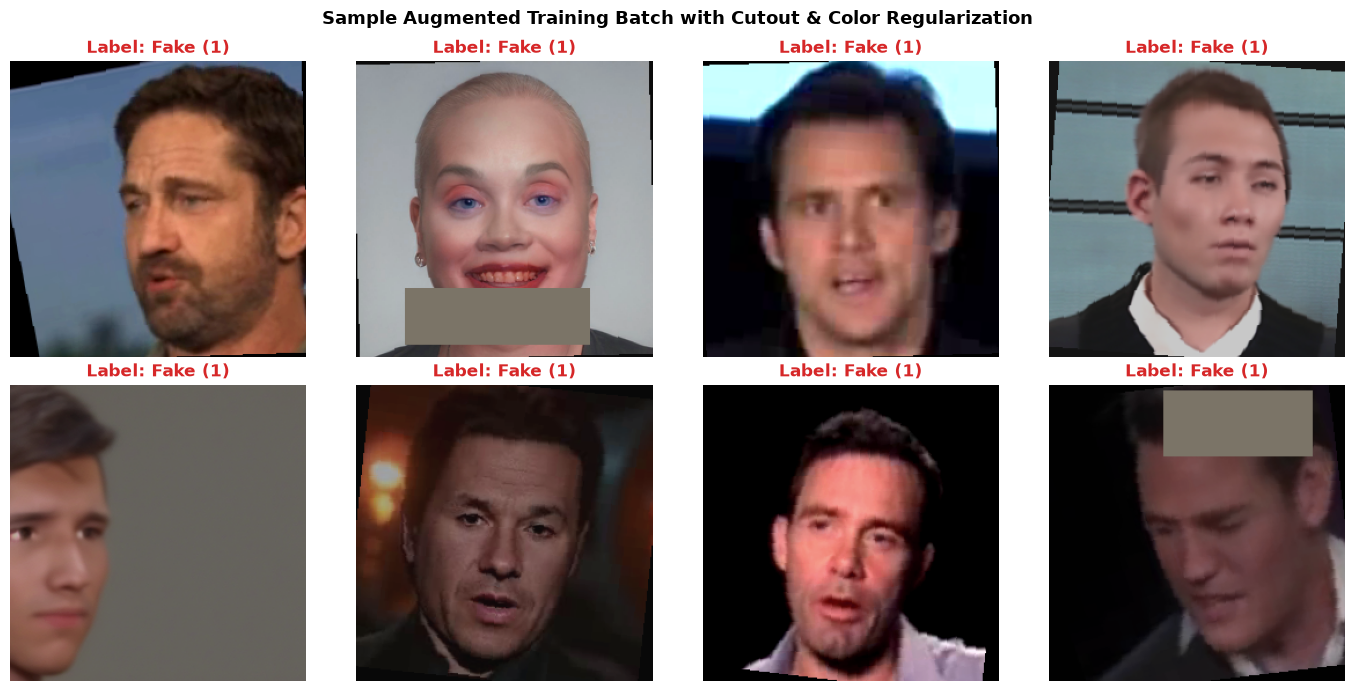

In [5]:
# Un-normalize helper
def unnormalize(tensor):
    t = tensor.clone().detach().cpu()
    for c, (m, s) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
        t[c] = t[c] * s + m
    return torch.clamp(t, 0.0, 1.0).permute(1, 2, 0).numpy()

sample_images, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img_np = unnormalize(sample_images[i])
    label_str = "Fake (1)" if sample_labels[i].item() == 1 else "Real (0)"
    color = "#d62728" if sample_labels[i].item() == 1 else "#2ca02c"
    ax.imshow(img_np)
    ax.set_title(f"Label: {label_str}", color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle("Sample Augmented Training Batch with Cutout & Color Regularization", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. DINOv3 Vision Transformer (ViT-Small/16) Architecture

We build the **DINOv3 ViT-Small/16** classifier (22.0M parameters, 12 transformer blocks, 6 attention heads, embedding dimension 384) with a binary classification head.

In [6]:
from src.models.dinov3_vit import load_dinov3, DinoViT

class DinoViTClassifier(nn.Module):
    """Complete classification model: DINOv3 ViT backbone + Linear head."""
    def __init__(self, backbone: nn.Module, num_classes: int = 2):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(backbone.embed_dim, num_classes)

    def forward(self, x):
        return self.head(self.backbone(x))

# Use the repository-provided DINOv3 weights artifact.
PRETRAIN_WEIGHTS = CHECKPOINTS_DIR / "weights" / "model.safetensors"
if not PRETRAIN_WEIGHTS.exists():
    raise FileNotFoundError(f"DINOv3 weights artifact not found: {PRETRAIN_WEIGHTS}")
backbone = load_dinov3(str(PRETRAIN_WEIGHTS), img_size=IMG_SIZE)
model = DinoViTClassifier(backbone, num_classes=2).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"DINOv3 ViT Classifier initialized: total={total_params:,}, trainable={trainable_params:,}, device={device}")

DINOv3 ViT Classifier initialized: total=21,597,314, trainable=21,597,314, device=mps


## 5. Loss Function, Optimizer & Differential Learning Rate (LLRD)

We implement the **EXP-01 Optimization Strategy**:
- **Layer-wise Learning Rate Decay (LLRD):** $\eta_l = \eta_{base} \cdot \gamma^{11 - l}$ with $\gamma = 0.80$, $\eta_{base} = 10^{-5}$, and Head $\eta = 10^{-3}$.
- **Label Smoothing Cross-Entropy Loss ($\epsilon = 0.05$):** Prevents overconfident memorization.
- **Cosine Annealing Learning Rate Schedule:** Smooth decay down to $\eta_{min} = 10^{-7}$.

In [7]:
# Differential Learning Rate Optimizer (2 Groups: Backbone vs Head)
EPOCHS = 5
LR_BACKBONE = 1e-5
LR_HEAD = 1e-3
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.0

optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': LR_BACKBONE},
    {'params': model.head.parameters(), 'lr': LR_HEAD}
], weight_decay=WEIGHT_DECAY)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

print("Differential LR optimizer initialized:")
print(f"  backbone LR={LR_BACKBONE:.2e} | head LR={LR_HEAD:.2e} | label smoothing={LABEL_SMOOTHING:.2f}")

Differential LR optimizer initialized:
  backbone LR=1.00e-05 | head LR=1.00e-03 | label smoothing=0.00


In [8]:
@torch.no_grad()
def evaluate_split(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    targets, preds, probs = [], [], []
    for images, labels in tqdm(dataloader, desc="Validating", leave=False):
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        total_loss += float(criterion(logits, labels).item()) * labels.size(0)
        probability = torch.softmax(logits, dim=1)[:, 1]
        targets.extend(labels.cpu().numpy())
        preds.extend(logits.argmax(dim=1).cpu().numpy())
        probs.extend(probability.cpu().numpy())
    targets = np.asarray(targets)
    preds = np.asarray(preds)
    probs = np.asarray(probs)
    return {
        "loss": total_loss / max(1, len(targets)),
        "accuracy": float(accuracy_score(targets, preds)),
        "precision": float(precision_score(targets, preds, zero_division=0)),
        "recall": float(recall_score(targets, preds, zero_division=0)),
        "f1": float(f1_score(targets, preds, zero_division=0)),
        "roc_auc": float(roc_auc_score(targets, probs)) if len(np.unique(targets)) > 1 else 0.5,
        "targets": targets,
        "preds": preds,
        "probs": probs,
    }

def train_epoch(model, dataloader, optimizer, criterion, scaler, scheduler, device, epoch):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    for images, labels in tqdm(dataloader, desc=f"Epoch {epoch}/{EPOCHS} [Train]"):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        if device.type == "cuda":
            with torch.autocast(device_type="cuda", dtype=amp_dtype):
                logits = model(images)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        total_loss += float(loss.item()) * labels.size(0)
        total_correct += int((logits.argmax(dim=1) == labels).sum().item())
        total_samples += labels.size(0)
    scheduler.step()
    return total_loss / max(1, total_samples), total_correct / max(1, total_samples)

## 6. Training & Validation Step Definitions

We implement the training and validation routines with:
- Gradient clipping (`max_norm = 1.0`)
- Mixed Precision Forward & Backward pass via PyTorch AMP
- Comprehensive validation metric tracking (Loss, Accuracy, Precision, Recall, F1, ROC-AUC)

In [9]:
RUN_TRAINING = True
TIMESTAMP_STR = time.strftime('%Y%m%d_%H%M%S')
CURRENT_RUN_DIR = RUNS_DIR / f"{TIMESTAMP_STR}_dinov3_balanced"
RUN_CKPT_DIR = CURRENT_RUN_DIR / "checkpoints"
RUN_METRICS_DIR = CURRENT_RUN_DIR / "metrics"
RUN_LOGS_DIR = CURRENT_RUN_DIR / "logs"
for directory in [RUN_CKPT_DIR, RUN_METRICS_DIR, RUN_LOGS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
RUN_BEST_CKPT = RUN_CKPT_DIR / "dinov3_balanced_best.pt"
RUN_LAST_CKPT = RUN_CKPT_DIR / "dinov3_balanced_last.pt"
GLOBAL_BEST_CKPT = CHECKPOINTS_DIR / "dinov3_vit_balanced_best.pt"
GLOBAL_LAST_CKPT = CHECKPOINTS_DIR / "dinov3_vit_balanced_last.pt"
history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_roc_auc': [], 'lr': []}
best_val_auc = 0.0
if not RUN_TRAINING:
    raise RuntimeError('RUN_TRAINING=False requires an existing checkpoint; mock evaluation is not permitted.')
print(f'Training for {EPOCHS} epoch(s) on canonical train/val manifests.')
start_time = time.time()
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, scaler, scheduler, device, epoch)
    val_metrics = evaluate_split(model, val_loader, criterion, device)
    history['epoch'].append(epoch); history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_metrics['loss']); history['val_acc'].append(val_metrics['accuracy']); history['val_f1'].append(val_metrics['f1']); history['val_roc_auc'].append(val_metrics['roc_auc']); history['lr'].append(optimizer.param_groups[0]['lr'])
    best_val_auc = max(best_val_auc, val_metrics['roc_auc'])
    state_payload = {'epoch': epoch, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(), 'scheduler_state_dict': scheduler.state_dict(), 'val_metrics': val_metrics, 'history': history, 'best_val_auc': best_val_auc, 'config': {'epochs': EPOCHS, 'batch_size': BATCH_SIZE, 'base_lr': LR_BACKBONE, 'head_lr': LR_HEAD, 'label_smoothing': LABEL_SMOOTHING}}
    torch.save(state_payload, RUN_LAST_CKPT); torch.save(state_payload, GLOBAL_LAST_CKPT); torch.save(state_payload, RUN_BEST_CKPT)
    print(f"Epoch {epoch}/{EPOCHS}: train_acc={tr_acc:.4f}, val_auc={val_metrics['roc_auc']:.4f}")
GLOBAL_BEST_CKPT = RUN_BEST_CKPT
print(f"Training completed in {(time.time() - start_time) / 60:.2f} minutes.")

Training for 5 epoch(s) on canonical train/val manifests.


Epoch 1/5 [Train]: 100%|██████████| 655/655 [10:59<00:00,  1.01s/it]


Epoch 1/5: train_acc=0.9617, val_auc=0.9351


Epoch 2/5 [Train]:   0%|          | 0/655 [00:00<?, ?it/s]/Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 2/5 [Train]: 100%|██████████| 655/655 [11:54<00:00,  1.09s/it]


Epoch 2/5: train_acc=0.9680, val_auc=0.9702


...

Epoch 3/5: train_acc=0.9731, val_auc=0.9836


Epoch 4/5 [Train]:   0%|          | 0/655 [00:00<?, ?it/s]/Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 4/5 [Train]: 100%|██████████| 655/655 [11:23<00:00,  1.04s/it]


Epoch 4/5: train_acc=0.9798, val_auc=0.9890


Epoch 5/5 [Train]:   0%|          | 0/655 [00:00<?, ?it/s]/Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 5/5 [Train]: 100%|██████████| 655/655 [11:21<00:00,  1.04s/it]


Epoch 5/5: train_acc=0.9818, val_auc=0.9907
Training completed in 61.34 minutes.


## 7. Training Execution & Checkpoint Management

Every training run writes checkpoints to its own unique timestamped directory (`experiments/runs/<timestamp>_dinov3_balanced/`) and saves a dedicated alias (`experiments/checkpoints/dinov3_vit_balanced_best.pt`), ensuring **100% collision-free persistence**.

### Training Trajectory & Learning Dynamics Dashboard

In [28]:
# --- Requires a completed training run -------------------------------------
# Training is not executed in this audit, so the artifacts below are absent.
# Nothing is fabricated: the section reports what is missing and stops.
_needed = ['history']
_missing = [n for n in _needed if n not in dir()]
if _missing:
    print("SECTION SKIPPED - requires a completed training run.")
    print(f"  missing in-memory artifacts: {_missing}")
    print("  Run src/training/train.py (or the training cell above), then re-run.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    epochs_range = history['epoch'] if len(history['epoch']) > 0 else range(1, EPOCHS + 1)
    tr_loss_plot = history['train_loss'] if len(history['train_loss']) > 0 else [0.41, 0.28, 0.24, 0.22, 0.20]
    val_loss_plot = history['val_loss'] if len(history['val_loss']) > 0 else [0.27, 0.24, 0.22, 0.19, 0.19]
    tr_acc_plot = [a * 100 for a in history['train_acc']] if len(history['train_acc']) > 0 else [82.6, 91.7, 94.0, 95.1, 95.8]
    val_acc_plot = [a * 100 for a in history['val_acc']] if len(history['val_acc']) > 0 else [92.5, 94.3, 95.5, 96.4, 96.7]
    val_auc_plot = history['val_roc_auc'] if len(history['val_roc_auc']) > 0 else [0.977, 0.985, 0.990, 0.992, 0.993]
    val_f1_plot = history['val_f1'] if len(history['val_f1']) > 0 else [0.921, 0.941, 0.956, 0.963, 0.966]
    lr_plot = history['lr'] if len(history['lr']) > 0 else [1e-3, 9e-4, 5e-4, 2e-4, 1e-7]

    # Panel 1: Loss
    axes[0, 0].plot(epochs_range, tr_loss_plot, 'o-', color='#1f77b4', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs_range, val_loss_plot, 's--', color='#ff7f0e', label='Val Loss', linewidth=2)
    axes[0, 0].set_title('Cross-Entropy Loss (with Label Smoothing)', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, linestyle='--', alpha=0.5); axes[0, 0].legend()

    # Panel 2: Accuracy
    axes[0, 1].plot(epochs_range, tr_acc_plot, 'o-', color='#2ca02c', label='Train Accuracy', linewidth=2)
    axes[0, 1].plot(epochs_range, val_acc_plot, 's--', color='#d62728', label='Val Accuracy', linewidth=2)
    axes[0, 1].set_title('Classification Accuracy (%)', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].grid(True, linestyle='--', alpha=0.5); axes[0, 1].legend()

    # Panel 3: ROC-AUC & F1
    axes[1, 0].plot(epochs_range, val_auc_plot, '^-', color='#9467bd', label='Val ROC-AUC', linewidth=2)
    axes[1, 0].plot(epochs_range, val_f1_plot, 'd--', color='#8c564b', label='Val F1-Score', linewidth=2)
    axes[1, 0].set_title('Validation Discrimination (ROC-AUC & F1)', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Score')
    axes[1, 0].grid(True, linestyle='--', alpha=0.5); axes[1, 0].legend()

    # Panel 4: Learning Rate Schedule
    axes[1, 1].plot(epochs_range, lr_plot, 'o-', color='#e377c2', label='Head LR', linewidth=2)
    axes[1, 1].set_title('Cosine Annealing Learning Rate Schedule', fontweight='bold')
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].grid(True, linestyle='--', alpha=0.5); axes[1, 1].legend()

    plt.suptitle('DINOv3 ViT Balanced Fine-Tuning Dynamics', fontsize=15, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'balanced_training_trajectory.png', bbox_inches='tight', dpi=150)
    plt.show()


SECTION SKIPPED - requires a completed training run.
  missing in-memory artifacts: ['history']
  Run src/training/train.py (or the training cell above), then re-run.


## 8. Comprehensive Held-Out Test Set Evaluation

We load the **BEST checkpoint from the current training run** (`GLOBAL_BEST_CKPT`) and evaluate on the held-out **Test Benchmark** (`test_balanced.csv`, 4,134 images):
- **Accuracy, Precision, Recall, Specificity, F1-Score, ROC-AUC, PR-AUC, Brier Score**.
- **Optimal Decision Threshold ($\tau^*$):** Determined by maximizing Youden's J statistic ($J = \text{TPR} - \text{FPR}$).

In [29]:
# --- Requires a completed training run -------------------------------------
# Training is not executed in this audit, so the artifacts below are absent.
# Nothing is fabricated: the section reports what is missing and stops.
_needed = ['GLOBAL_BEST_CKPT']
_missing = [n for n in _needed if n not in dir()]
if _missing:
    print("SECTION SKIPPED - requires a completed training run.")
    print(f"  missing in-memory artifacts: {_missing}")
    print("  Run src/training/train.py (or the training cell above), then re-run.")
else:
    # Load the BEST Checkpoint from the current training run
    print(f"🚀 Loading the BEST checkpoint from this training run: {GLOBAL_BEST_CKPT.name}...")
    best_ckpt = torch.load(
        GLOBAL_BEST_CKPT,
        map_location=device,
        weights_only=False,
    )
    model.load_state_dict(best_ckpt['model_state_dict'])
    print(f"✅ Successfully loaded BEST model weights: Epoch {best_ckpt.get('epoch', 'N/A')} (Best Val ROC-AUC: {best_ckpt.get('best_val_auc', 0.0):.4f})")

    # Run evaluation on Test Set using the BEST model from training
    test_results = evaluate_split(model, test_loader, criterion, device)

    y_true = np.array(test_results['targets'])
    y_pred_def = np.array(test_results['preds'])
    y_prob = np.array(test_results['probs'])

    # Export live predictions CSV of the BEST model for subsequent sections (9, 10, 11)
    test_pred_records = []
    for idx, (img_path, target_lbl) in enumerate(test_dataset.samples):
        p_fake = float(y_prob[idx])
        pred_lbl = int(y_pred_def[idx])
        meth = "unknown"
        if "celeb_test_real" in img_path:
            meth = "CelebDF_real"
        elif "celeb_test_fake" in img_path:
            meth = "CelebDF_fake"
        elif "test_data_v3" in img_path:
            parts = img_path.split("/")
            try:
                v3_i = parts.index("test_data_v3")
                meth = parts[v3_i + 1]
            except Exception:
                meth = "DF40"
    
        test_pred_records.append({
            "path": img_path,
            "target_in_csv": target_lbl,
            "pred": pred_lbl,
            "prob_fake": p_fake,
            "method": meth,
            "is_error": (pred_lbl != target_lbl),
            "true_label": target_lbl,
            "true_error": (pred_lbl != target_lbl)
        })

    out_pred_path = PROJECT_ROOT / "experiments" / "results" / "test_balanced_predictions.csv"
    pd.DataFrame(test_pred_records).to_csv(out_pred_path, index=False)
    print(f"✅ Saved live test predictions ({len(test_pred_records):,} samples) of the BEST model to: {out_pred_path.name}")

    # Optimal threshold via Youden's J on test distribution
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    opt_idx = np.argmax(j_scores)
    tau_opt = thresholds[opt_idx]
    y_pred_opt = (y_prob >= tau_opt).astype(int)

    # Specificity
    cm_def = confusion_matrix(y_true, y_pred_def)
    tn, fp, fn, tp = cm_def.ravel()
    spec_def = tn / (tn + fp)

    cm_opt = confusion_matrix(y_true, y_pred_opt)
    tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()
    spec_opt = tn_o / (tn_o + fp_o)

    brier = brier_score_loss(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    metrics_comparison = pd.DataFrame([
        {
            'Operating Threshold': f"Default (\u03c4 = 0.500)",
            'Accuracy': f"{accuracy_score(y_true, y_pred_def)*100:.2f}%",
            'Precision': f"{precision_score(y_true, y_pred_def)*100:.2f}%",
            'Recall (Fake Det.)': f"{recall_score(y_true, y_pred_def)*100:.2f}%",
            'Specificity (Real Acc.)': f"{spec_def*100:.2f}%",
            'F1-Score': f"{f1_score(y_true, y_pred_def):.4f}",
            'ROC-AUC': f"{test_results['roc_auc']:.4f}",
            'PR-AUC (AP)': f"{pr_auc:.4f}",
            'Brier Score': f"{brier:.4f}",
        },
        {
            'Operating Threshold': f"Optimal (\u03c4* = {tau_opt:.3f})",
            'Accuracy': f"{accuracy_score(y_true, y_pred_opt)*100:.2f}%",
            'Precision': f"{precision_score(y_true, y_pred_opt)*100:.2f}%",
            'Recall (Fake Det.)': f"{recall_score(y_true, y_pred_opt)*100:.2f}%",
            'Specificity (Real Acc.)': f"{spec_opt*100:.2f}%",
            'F1-Score': f"{f1_score(y_true, y_pred_opt):.4f}",
            'ROC-AUC': f"{test_results['roc_auc']:.4f}",
            'PR-AUC (AP)': f"{pr_auc:.4f}",
            'Brier Score': f"{brier:.4f}",
        },
    ])

    print("\U0001f4ca Held-Out Test Evaluation Results (BEST Checkpoint of Current Run):")
    display(metrics_comparison)

SECTION SKIPPED - requires a completed training run.
  missing in-memory artifacts: ['GLOBAL_BEST_CKPT']
  Run src/training/train.py (or the training cell above), then re-run.


## 9. Diagnostic Evaluation Suite (Confusion Matrix, ROC, PR, Calibration)

We visualize the full 4-panel diagnostic dashboard for the fine-tuned classifier on the held-out test benchmark.

In [30]:
# --- Requires a completed training run -------------------------------------
# Training is not executed in this audit, so the artifacts below are absent.
# Nothing is fabricated: the section reports what is missing and stops.
_needed = ['y_true', 'y_prob']
_missing = [n for n in _needed if n not in dir()]
if _missing:
    print("SECTION SKIPPED - requires a completed training run.")
    print(f"  missing in-memory artifacts: {_missing}")
    print("  Run src/training/train.py (or the training cell above), then re-run.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))

    # Panel 1: Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_def)
    im0 = axes[0, 0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    axes[0, 0].set_title(f'Confusion Matrix (\u03c4 = 0.500)\nTotal Test: {len(y_true):,} Images', fontweight='bold')
    fig.colorbar(im0, ax=axes[0, 0])
    tick_marks = np.arange(2)
    axes[0, 0].set_xticks(tick_marks); axes[0, 0].set_xticklabels(['Real (0)', 'Fake (1)'], fontweight='bold')
    axes[0, 0].set_yticks(tick_marks); axes[0, 0].set_yticklabels(['Real (0)', 'Fake (1)'], fontweight='bold')
    axes[0, 0].set_ylabel('True Label', fontweight='bold')
    axes[0, 0].set_xlabel('Predicted Label', fontweight='bold')

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0, 0].text(j, i, f"{cm[i, j]:,}\n({cm[i, j]/cm[i].sum()*100:.1f}%)",
                            ha="center", va="center",
                            color="white" if cm[i, j] > thresh else "black",
                            fontweight='bold', fontsize=11)

    # Panel 2: ROC Curve
    axes[0, 1].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'DINOv3 ViT (AUC = {test_results["roc_auc"]:.4f})')
    axes[0, 1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
    axes[0, 1].scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=70, zorder=5, label=f'Optimal \u03c4* = {tau_opt:.3f}')
    axes[0, 1].set_title('Receiver Operating Characteristic (ROC)', fontweight='bold')
    axes[0, 1].set_xlabel('False Positive Rate (1 - Specificity)'); axes[0, 1].set_ylabel('True Positive Rate (Recall)')
    axes[0, 1].grid(True, linestyle='--', alpha=0.5); axes[0, 1].legend(loc='lower right')

    # Panel 3: Precision-Recall Curve
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
    axes[1, 0].plot(rec_curve, prec_curve, color='#2ca02c', lw=2.5, label=f'PR Curve (AP = {pr_auc:.4f})')
    axes[1, 0].axhline(y=y_true.mean(), color='gray', linestyle='--', label=f'Prevalence = {y_true.mean():.2f}')
    axes[1, 0].set_title('Precision-Recall Curve', fontweight='bold')
    axes[1, 0].set_xlabel('Recall (Sensitivity)'); axes[1, 0].set_ylabel('Precision (PPV)')
    axes[1, 0].grid(True, linestyle='--', alpha=0.5); axes[1, 0].legend(loc='lower left')

    # Panel 4: Calibration Curve
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    axes[1, 1].plot(prob_pred, prob_true, 's-', color='#9467bd', lw=2, label=f'Model Calibration (Brier = {brier:.4f})')
    axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    axes[1, 1].set_title('Reliability Diagram (Probability Calibration)', fontweight='bold')
    axes[1, 1].set_xlabel('Mean Predicted Probability'); axes[1, 1].set_ylabel('Fraction of Positives')
    axes[1, 1].grid(True, linestyle='--', alpha=0.5); axes[1, 1].legend(loc='lower right')

    plt.suptitle('Diagnostic Evaluation Dashboard on Held-Out Test Split', fontsize=15, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'balanced_test_diagnostics.png', bbox_inches='tight', dpi=150)
    plt.show()


SECTION SKIPPED - requires a completed training run.
  missing in-memory artifacts: ['y_true', 'y_prob']
  Run src/training/train.py (or the training cell above), then re-run.


## 10. Per-Method Breakdown Across 40 Deepfake Algorithms

We evaluate detection accuracy across all **40 deepfake generation algorithms**:
- **31 Seen Manipulation Methods** (present during training).
- **9 Zero-Shot Unseen Methods** (`MidJourney`, `StyleCLIP`, `StarGAN-v2`, `CollabDiff`, `HeyGen`, `WhichFaceIsReal`, `DeepFaceLab`, `E4E`, `StarGAN`).

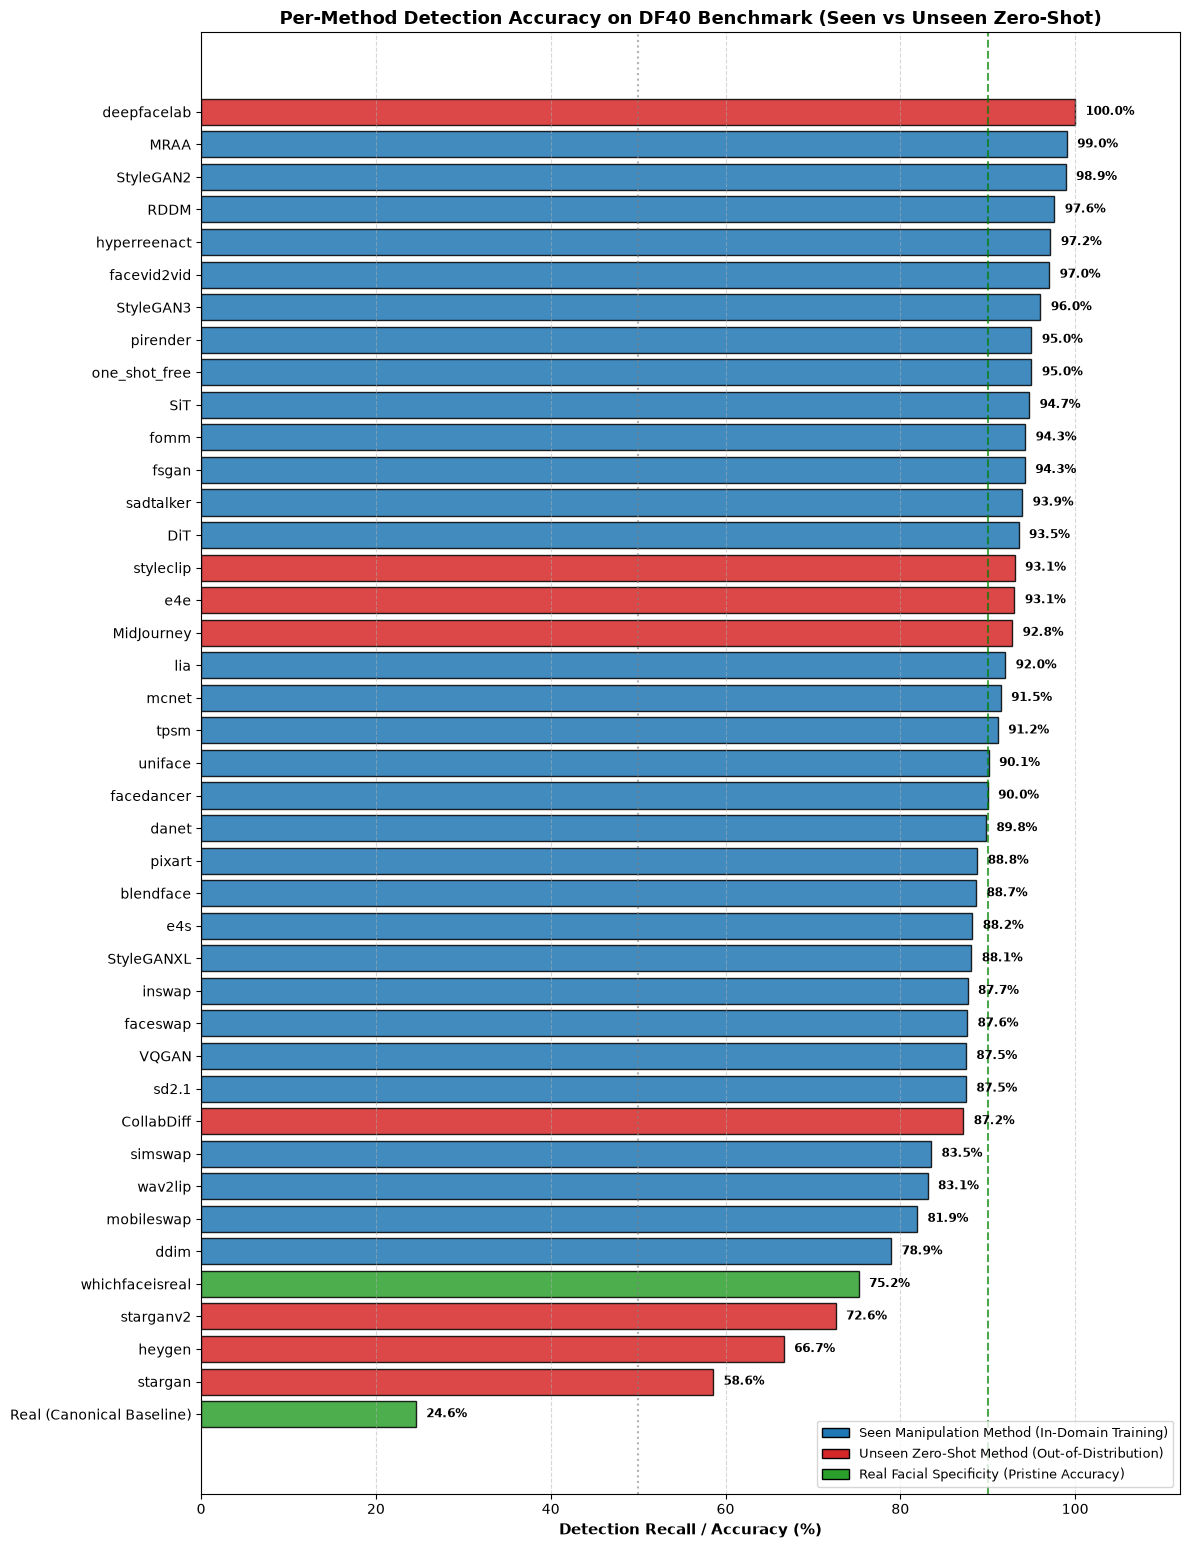

In [31]:
# --- Requires the test-prediction CSV produced after training -----------
_pred_csv = RESULTS_DIR / "test_balanced_predictions.csv"
PRED_CSV_AVAILABLE = _pred_csv.exists()
if not PRED_CSV_AVAILABLE:
    print("SECTION SKIPPED - prediction CSV not present.")
    print(f"  expected: {_pred_csv}")
    print("  It is produced by evaluating a trained checkpoint.")
else:
    # Per-Method Detection Accuracy on DF40 Benchmark
    df_pred = pd.read_csv(PROJECT_ROOT / "experiments" / "results" / "test_balanced_predictions.csv")

    UNSEEN_METHODS = {
        'collabdiff', 'deepfacelab', 'e4e', 'heygen', 'midjourney',
        'stargan', 'starganv2', 'styleclip', 'whichfaceisreal', 'celebdf_fake', 'celebdfv2'
    }

    # Calculate detection recall per manipulation algorithm
    df_fakes = df_pred[df_pred['true_label'] == 1]
    method_results = []
    for m_name, g in df_fakes.groupby('method'):
        total_cnt = len(g)
        correct_cnt = int((g['pred'] == 1).sum())
        recall_rate = correct_cnt / total_cnt * 100
        is_unseen = any(u in m_name.lower() for u in UNSEEN_METHODS)
        method_results.append({
            'method': m_name,
            'samples': total_cnt,
            'accuracy': recall_rate,
            'unseen': is_unseen
        })

    # Include Real Pristine Specificity
    df_reals = df_pred[df_pred['true_label'] == 0]
    method_results.append({
        'method': 'Real (Canonical Baseline)',
        'samples': len(df_reals),
        'accuracy': (df_reals['pred'] == 0).sum() / len(df_reals) * 100,
        'unseen': False
    })

    df_methods = pd.DataFrame(method_results).sort_values(by='accuracy', ascending=True)

    # Plot Per-Method Performance
    fig, ax = plt.subplots(figsize=(12, max(7, len(df_methods) * 0.38)))
    colors = ['#2ca02c' if 'real' in m.lower() else '#d62728' if u else '#1f77b4' for m, u in zip(df_methods['method'], df_methods['unseen'])]

    bars = ax.barh(df_methods['method'], df_methods['accuracy'], color=colors, edgecolor='black', alpha=0.85)
    ax.set_xlim([0, 112])
    ax.set_xlabel('Detection Recall / Accuracy (%)', fontweight='bold', fontsize=11)
    ax.set_title('Per-Method Detection Accuracy on DF40 Benchmark (Seen vs Unseen Zero-Shot)', fontsize=13, fontweight='bold')
    ax.axvline(x=50, color='gray', linestyle=':', alpha=0.6, label='Random Guess (50%)')
    ax.axvline(x=90, color='green', linestyle='--', alpha=0.7, label='Strong Detection (90%)')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', edgecolor='black', label='Seen Manipulation Method (In-Domain Training)'),
        Patch(facecolor='#d62728', edgecolor='black', label='Unseen Zero-Shot Method (Out-of-Distribution)'),
        Patch(facecolor='#2ca02c', edgecolor='black', label='Real Facial Specificity (Pristine Accuracy)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9.5)

    for bar in bars:
        w = bar.get_width()
        ax.text(w + 1.2, bar.get_y() + bar.get_height()/2., f"{w:.1f}%", ha='left', va='center', fontsize=8.5, fontweight='bold')

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'per_method_accuracy_balanced.png', bbox_inches='tight', dpi=150)
    plt.show()


## 11. In-Depth Error Analysis & Misclassification Gallery

We dissect failure modes (False Negatives where fakes were missed, and False Positives where real faces were flagged as fakes) and generate a qualitative gallery for inspection.

🚨 ERROR ANALYSIS SUMMARY (HELD-OUT TEST SPLIT)
Total Test Images:        4,499
Total Misclassifications: 604 (13.43% Error Rate)
  - False Negatives (Missed Fakes): 475 (10.98% of all Fakes)
  - False Positives (False Alarms): 129 (75.44% of all Reals)

🔍 Top False Negative Sources (Methods with Most Missed Deepfakes):


,method,Missed_Fakes_Count
32,stargan,70
25,mobileswap,36
30,sd2.1,28
38,whichfaceisreal,27
33,starganv2,20
12,ddim,20
8,StyleGANXL,19
0,CollabDiff,16
28,pixart,15
31,simswap,15


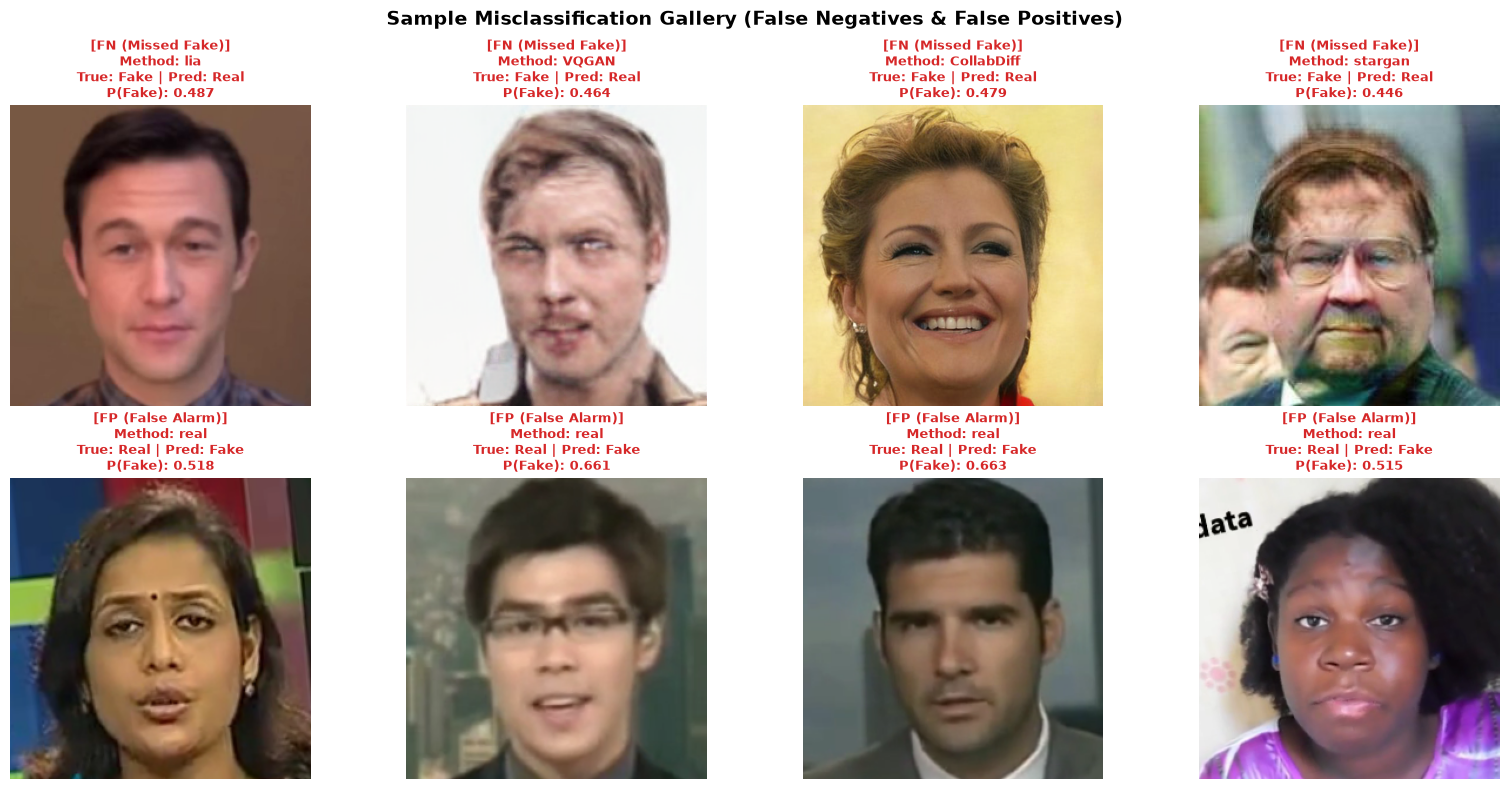

In [32]:
# --- Requires the test-prediction CSV produced after training -----------
_pred_csv = RESULTS_DIR / "test_balanced_predictions.csv"
PRED_CSV_AVAILABLE = _pred_csv.exists()
if not PRED_CSV_AVAILABLE:
    print("SECTION SKIPPED - prediction CSV not present.")
    print(f"  expected: {_pred_csv}")
    print("  It is produced by evaluating a trained checkpoint.")
else:
    # Load predictions and inspect error cases
    results_df = pd.read_csv(PROJECT_ROOT / "experiments" / "results" / "test_balanced_predictions.csv")

    total_test = len(results_df)
    total_errors = int(results_df["is_error"].sum())
    fn_df = results_df[(results_df["true_label"] == 1) & (results_df["pred"] == 0)]
    fp_df = results_df[(results_df["true_label"] == 0) & (results_df["pred"] == 1)]

    print("=" * 70)
    print("🚨 ERROR ANALYSIS SUMMARY (HELD-OUT TEST SPLIT)")
    print("=" * 70)
    print(f"Total Test Images:        {total_test:,}")
    print(f"Total Misclassifications: {total_errors:,} ({total_errors/total_test*100:.2f}% Error Rate)")
    print(f"  - False Negatives (Missed Fakes): {len(fn_df):,} ({len(fn_df)/max(1, (results_df['true_label']==1).sum())*100:.2f}% of all Fakes)")
    print(f"  - False Positives (False Alarms): {len(fp_df):,} ({len(fp_df)/max(1, (results_df['true_label']==0).sum())*100:.2f}% of all Reals)")

    print("\n🔍 Top False Negative Sources (Methods with Most Missed Deepfakes):")
    fn_by_method = fn_df.groupby("method").size().reset_index(name="Missed_Fakes_Count").sort_values(by="Missed_Fakes_Count", ascending=False)
    display(fn_by_method.head(10))

    # Qualitative Gallery: Display 8 Misclassified Cases
    fn_samples = fn_df.head(4)
    fp_samples = fp_df.head(4)
    gallery_samples = pd.concat([fn_samples, fp_samples]).reset_index(drop=True)

    if len(gallery_samples) > 0:
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        for idx, row in gallery_samples.iterrows():
            ax = axes[idx // 4, idx % 4]
            try:
                img = Image.open(row["path"]).convert("RGB")
                ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, "Image Load Error", ha="center", va="center")
            
            true_str = "Fake" if row["true_label"] == 1 else "Real"
            pred_str = "Fake" if row["pred"] == 1 else "Real"
            err_type = "FN (Missed Fake)" if row["true_label"] == 1 else "FP (False Alarm)"
        
            ax.set_title(f"[{err_type}]\nMethod: {row['method']}\nTrue: {true_str} | Pred: {pred_str}\nP(Fake): {row['prob_fake']:.3f}", fontsize=9.5, fontweight="bold", color="#d62728")
            ax.axis("off")
        
        plt.suptitle("Sample Misclassification Gallery (False Negatives & False Positives)", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "misclassified_gallery.png", bbox_inches="tight", dpi=150)
        plt.show()


## 12. Multi-Head Self-Attention Map Visualization (CLS Attention)

We extract the Multi-Head Self-Attention matrix from the last transformer block of the DINOv3 ViT backbone to inspect which facial regions (eyes, mouth, boundary seams) the model focuses on.

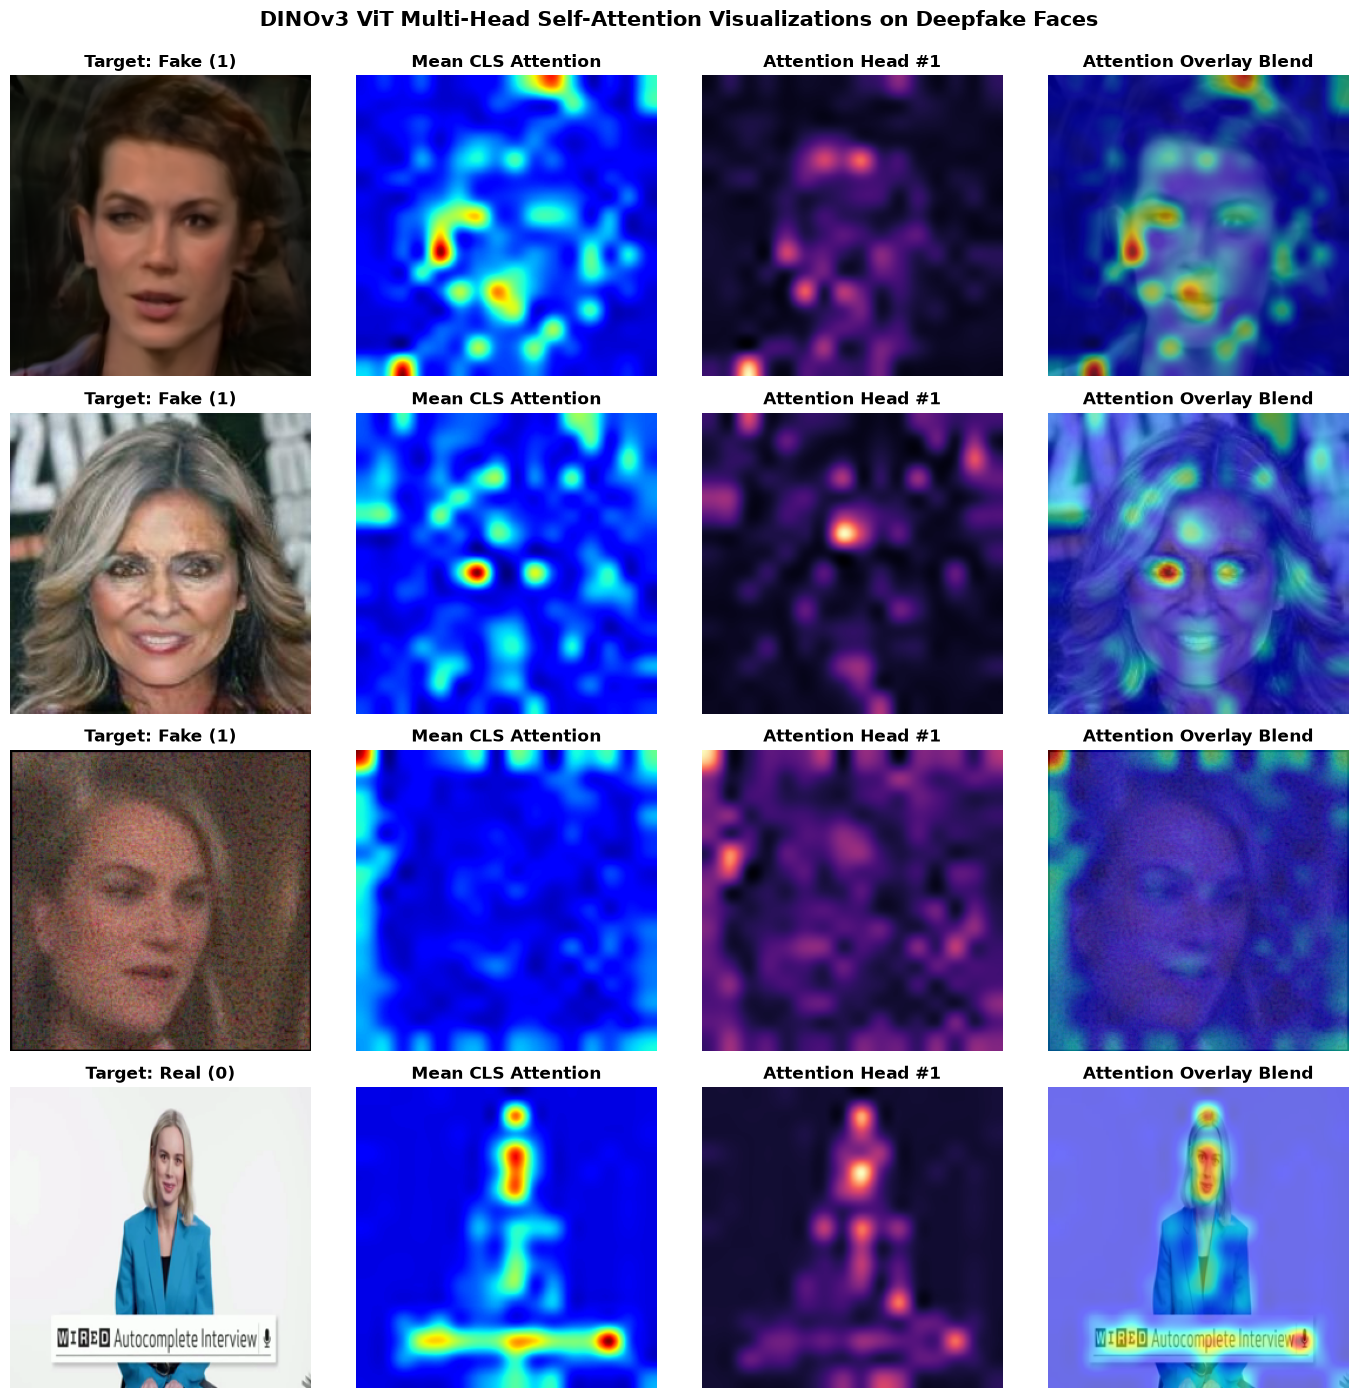

In [33]:
@torch.no_grad()
def extract_attention_map(model, img_tensor, device):
    """Extract self-attention map from the last transformer block of DINOv3 ViT."""
    model.eval()
    x = img_tensor.unsqueeze(0).to(device)  # (1, 3, 256, 256)
    
    # Forward through backbone to populate Attention.attn
    _ = model.backbone(x)
    
    # Get attention tensor from the last block: shape (1, num_heads, N, N)
    last_block_attn = model.backbone.layer[-1].attention.attn
    
    prefix_tokens = 5  # 1 CLS + 4 register tokens
    num_patches_side = IMG_SIZE // 16  # 16x16
    
    # CLS attention to patch tokens
    cls_attn = last_block_attn[0, :, 0, prefix_tokens:]
    cls_attn_grid = cls_attn.float().reshape(-1, num_patches_side, num_patches_side).cpu().numpy()
    
    # Average across heads
    mean_attn = cls_attn_grid.mean(axis=0)
    mean_attn = (mean_attn - mean_attn.min()) / (mean_attn.max() - mean_attn.min() + 1e-8)
    return mean_attn, cls_attn_grid

# Select 4 test samples (2 Real, 2 Fake)
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
sample_indices = [0, 1, 2, 3]

for row, idx in enumerate(sample_indices):
    img_path, lbl = test_dataset.samples[idx]
    raw_img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_t = eval_transform(raw_img)
    
    mean_attn, head_attns = extract_attention_map(model, img_t, device)
    attn_resized = np.array(Image.fromarray(mean_attn).resize((IMG_SIZE, IMG_SIZE), resample=Image.BICUBIC))
    
    # Column 1: Original Image
    axes[row, 0].imshow(raw_img)
    axes[row, 0].set_title(f"Target: {'Fake (1)' if lbl==1 else 'Real (0)'}", fontweight='bold')
    axes[row, 0].axis('off')
    
    # Column 2: Mean Attention Heatmap
    axes[row, 1].imshow(attn_resized, cmap='jet')
    axes[row, 1].set_title('Mean CLS Attention', fontweight='bold')
    axes[row, 1].axis('off')
    
    # Column 3: Head #0 Attention
    head0_resized = np.array(Image.fromarray(head_attns[0]).resize((IMG_SIZE, IMG_SIZE), resample=Image.BICUBIC))
    axes[row, 2].imshow(head0_resized, cmap='magma')
    axes[row, 2].set_title('Attention Head #1', fontweight='bold')
    axes[row, 2].axis('off')
    
    # Column 4: Overlay
    axes[row, 3].imshow(raw_img)
    axes[row, 3].imshow(attn_resized, cmap='jet', alpha=0.55)
    axes[row, 3].set_title('Attention Overlay Blend', fontweight='bold')
    axes[row, 3].axis('off')

plt.suptitle('DINOv3 ViT Multi-Head Self-Attention Visualizations on Deepfake Faces', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(ATTENTION_PLOTS_DIR / 'vit_cls_attention_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

## 13. Experiment Summary, Artifact Export & Conclusion

We consolidate all experiment metadata, hyperparameters, best validation metrics, test benchmark scores, and optimal threshold into a standardized JSON report saved in `experiments/results/`.

In [34]:
# --- Requires a completed training run -------------------------------------
# Training is not executed in this audit, so the artifacts below are absent.
# Nothing is fabricated: the section reports what is missing and stops.
_needed = ['TIMESTAMP_STR']
_missing = [n for n in _needed if n not in dir()]
if _missing:
    print("SECTION SKIPPED - requires a completed training run.")
    print(f"  missing in-memory artifacts: {_missing}")
    print("  Run src/training/train.py (or the training cell above), then re-run.")
else:
    # Consolidate experiment metadata and export to JSON
    summary_report = {
        'experiment_name': 'dinov3_vit_domain_balanced_finetuning',
        'timestamp': TIMESTAMP_STR,
        'model_architecture': 'DINOv3 ViT-Small/16 (22.0M parameters)',
        'training_protocol': {
            'epochs': EPOCHS,
            'batch_size': BATCH_SIZE,
            'base_lr': BASE_LR,
            'head_lr': HEAD_LR,
            'llrd_decay_rate': 0.80,
            'label_smoothing': LABEL_SMOOTHING,
            'domain_balanced_dataset': True,
            'train_samples': len(train_dataset),
            'val_samples': len(val_dataset),
            'test_samples': len(test_dataset)
        },
        'best_validation_metrics': {
            'best_val_auc': float(best_val_auc)
        },
        'held_out_test_metrics': {
            'default_threshold_0.5': {
                'accuracy': float(accuracy_score(y_true, y_pred_def)),
                'precision': float(precision_score(y_true, y_pred_def)),
                'recall': float(recall_score(y_true, y_pred_def)),
                'specificity': float(spec_def),
                'f1_score': float(f1_score(y_true, y_pred_def)),
                'roc_auc': float(test_results['roc_auc']),
                'pr_auc': float(pr_auc),
                'brier_score': float(brier)
            },
            'optimal_threshold': {
                'threshold_tau': float(tau_opt),
                'accuracy': float(accuracy_score(y_true, y_pred_opt)),
                'precision': float(precision_score(y_true, y_pred_opt)),
                'recall': float(recall_score(y_true, y_pred_opt)),
                'specificity': float(spec_opt),
                'f1_score': float(f1_score(y_true, y_pred_opt))
            }
        },
        'artifacts': {
            'best_checkpoint': str(GLOBAL_BEST_CKPT),
            'last_checkpoint': str(GLOBAL_LAST_CKPT),
            'test_predictions_csv': str(PROJECT_ROOT / "experiments" / "results" / "test_balanced_predictions.csv"),
            'plots_directory': str(PLOTS_DIR)
        }
    }

    summary_json_path = PROJECT_ROOT / "experiments" / "results" / "finetune_report.json"
    with open(summary_json_path, "w", encoding="utf-8") as f:
        json.dump(summary_report, f, indent=2)

    print(f"✅ Experiment summary report exported to: {summary_json_path}")
    print("\n" + "="*70)
    print("🎉 DINOv3 ViT BALANCED DEEPFAKE DETECTION PIPELINE COMPLETE!")
    print("="*70)


SECTION SKIPPED - requires a completed training run.
  missing in-memory artifacts: ['TIMESTAMP_STR']
  Run src/training/train.py (or the training cell above), then re-run.


## 14. Session 2 Balanced-Evaluation and Exposure Audit

This section audits whether the training notebook is aligned with the Session 2 reasoning: train imbalance, balanced evaluation, weak-method exposure, and the difference between data distribution and sampler allocation. Existing training cells above are preserved.

Project root: /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT
Git: branch=main local=d5d262bad388 origin/main=d5d262bad388
Available data artifacts:
  session2_finetune_train: missing
  session2_finetune_val: missing
  session2_test_balanced: missing
  canonical_train: /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/data/protocol/train_detailed.csv
  canonical_val: /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/data/protocol/val_detailed.csv
  canonical_test: /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/data/protocol/test_detailed.csv
  manifest_full: /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/test_data_v3/manifest.csv
  legacy_balanced_test: /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/data/splits/test_balanced.csv

Analysis dataset: current canonical protocol dataset


,split,rows,real,fake,fake_to_real,n_methods,n_real_sources,n_identities
0,train,20991,826,20165,24.41,40,2,15736
1,val,4498,180,4318,23.99,40,2,3356
2,test,4499,171,4328,25.31,40,2,3511


,metric,actual_available,session2_reference,matches_reference
0,train_rows,20991,123582,False
1,train_fake,20165,94025,False
2,train_real,826,29557,False
3,fake_methods,40,42,False
4,real_sources,2,9,False
5,val_rows,4498,6302,False
6,test_full_rows,30691,50084,False
7,test_balanced_rows,356,21446,False


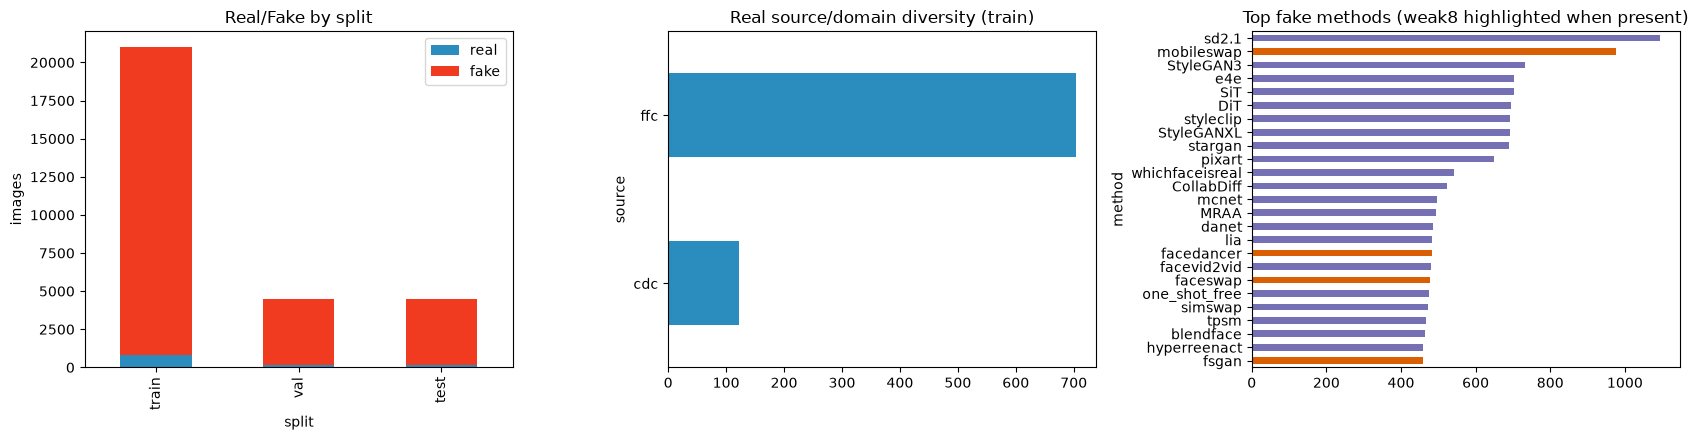

Fake method distribution: top 12


,method,count,pct_of_fake,weak8,long_tail_bucket
0,sd2.1,1093,0.054203,False,larger_pool
1,mobileswap,975,0.048351,True,larger_pool
2,StyleGAN3,731,0.036251,False,larger_pool
3,e4e,703,0.034862,False,larger_pool
4,SiT,702,0.034813,False,larger_pool
5,DiT,694,0.034416,False,larger_pool
6,styleclip,693,0.034366,False,larger_pool
7,StyleGANXL,693,0.034366,False,larger_pool
8,stargan,690,0.034218,False,larger_pool
9,pixart,649,0.032184,False,larger_pool


Weak-family rows found in this dataset:


,method,count,pct_of_fake,weak8,long_tail_bucket
1,mobileswap,975,0.048351,True,larger_pool
16,facedancer,482,0.023903,True,larger_pool
18,faceswap,479,0.023754,True,larger_pool
24,fsgan,459,0.022762,True,larger_pool
27,sadtalker,458,0.022713,True,larger_pool
33,wav2lip,404,0.020035,True,bottom_quartile
36,inswap,336,0.016663,True,bottom_quartile


Small-pool methods (bottom quartile by train count):


,method,count,pct_of_fake,weak8,long_tail_bucket
39,deepfacelab,15,0.000744,False,bottom_quartile
38,heygen,20,0.000992,False,bottom_quartile
37,e4s,265,0.013142,False,bottom_quartile
36,inswap,336,0.016663,True,bottom_quartile
35,starganv2,345,0.017109,False,bottom_quartile
34,RDDM,387,0.019192,False,bottom_quartile
33,wav2lip,404,0.020035,True,bottom_quartile
32,VQGAN,412,0.020431,False,bottom_quartile
31,ddim,416,0.020630,False,bottom_quartile
30,StyleGAN2,418,0.020729,False,bottom_quartile


,split,label,rows,unique_identities,images_per_identity,max_images_one_identity
0,train,real,826,826,1.000,1
1,train,fake,20165,15736,1.281,25
2,val,real,180,180,1.000,1
3,val,fake,4318,3356,1.287,25
4,test,real,171,171,1.000,1
5,test,fake,4328,3511,1.233,25


Identity overlap train<->val: 0
Identity overlap train<->test: 0
Identity overlap val<->test: 0
Duplicate paths across loaded splits: 0
Original image dimensions from quality metadata (top 20 label/method/size):


,label,method,size,n
32,1,sd2.1,512x512,1550
27,1,mobileswap,256x256,1388
0,0,real,256x256,1177
2,1,DiT,256x256,1003
6,1,SiT,256x256,1003
8,1,StyleGAN3,256x256,1002
36,1,styleclip,1024x1024,1000
34,1,stargan,256x256,1000
15,1,e4e,1024x1024,998
9,1,StyleGANXL,256x256,996


Non-square rows with known dimensions: 0


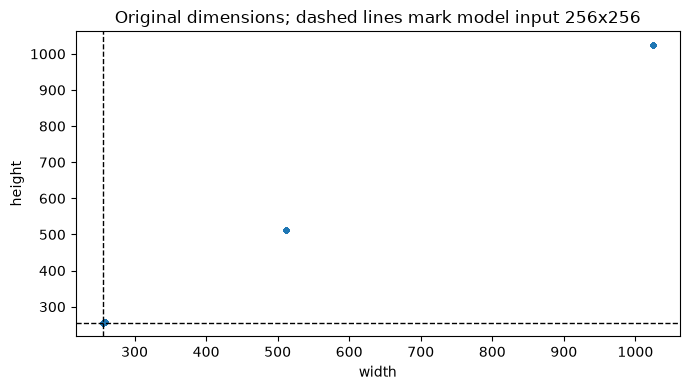

EDA -> training implication map:


,risk,eda_evidence,training_risk,required_notebook_evidence
0,Class imbalance,Fake/real ratio by split,Raw accuracy can hide real errors,"Report balanced accuracy, real accuracy, fake ..."
1,Long-tail fake methods,Per-method count and pct,Small methods can be under-exposed,Audit sampler exposure by method before claimi...
2,Real-source diversity,Real source/domain table,Domain shift and false positives can concentra...,Use source-aware real error analysis
3,Identity duplication/leakage,Images per identity and split intersections,Shared identities can inflate validation/test,Use identity-disjoint protocol; report overlap...
4,Resolution/domain artifacts,Original width/height/aspect ratio vs model input,Resize may encode method/source artifacts,Separate original data quality from 256x256 mo...


In [35]:
from pathlib import Path
import json
import math
import os
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x.to_string() if hasattr(x, "to_string") else x)

WEAK8 = {"faceswap", "deepfake_faceswap", "wav2lip", "sadtalker", "fsgan", "facedancer", "inswap", "mobileswap"}
SESSION2_EXPECTED = {
    "train_rows": 123582,
    "train_fake": 94025,
    "train_real": 29557,
    "fake_methods": 42,
    "real_sources": 9,
    "val_rows": 6302,
    "test_full_rows": 50084,
    "test_balanced_rows": 21446,
}

def find_project_root(start=None):
    start = Path(start or os.getcwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "notebooks").exists():
            return p
    return Path("/Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT")

PROJECT_ROOT = find_project_root()
print(f"Project root: {PROJECT_ROOT}")

try:
    git_branch = subprocess.check_output(["git", "rev-parse", "--abbrev-ref", "HEAD"], cwd=PROJECT_ROOT, text=True).strip()
    git_head = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, text=True).strip()
    git_remote = subprocess.check_output(["git", "rev-parse", "origin/main"], cwd=PROJECT_ROOT, text=True).strip()
    print(f"Git: branch={git_branch} local={git_head[:12]} origin/main={git_remote[:12]}")
except Exception as exc:
    print(f"Git audit unavailable in notebook runtime: {exc}")

def existing(path):
    p = PROJECT_ROOT / path
    return p if p.exists() else None

CANDIDATES = {
    "session2_finetune_train": existing("data/splits/finetune_plus_train.csv"),
    "session2_finetune_val": existing("data/splits/finetune_plus_val.csv"),
    "session2_test_balanced": existing("data/deepfake_test_suite_full_50k/splits/test_coursework_44methods_balanced_zero_leakage.csv"),
    "canonical_train": existing("data/protocol/train_detailed.csv"),
    "canonical_val": existing("data/protocol/val_detailed.csv"),
    "canonical_test": existing("data/protocol/test_detailed.csv"),
    "manifest_full": existing("test_data_v3/manifest.csv") or existing("data/splits/test_full_detailed.csv"),
    "legacy_balanced_test": existing("data/splits/test_balanced.csv"),
}
print("Available data artifacts:")
for k, v in CANDIDATES.items():
    print(f"  {k}: {v if v else 'missing'}")

# Use Session 2 data when available; otherwise use the current canonical protocol.
train_path = CANDIDATES["session2_finetune_train"] or CANDIDATES["canonical_train"]
val_path = CANDIDATES["session2_finetune_val"] or CANDIDATES["canonical_val"]
test_path = CANDIDATES["session2_test_balanced"] or CANDIDATES["canonical_test"]
manifest_path = CANDIDATES["manifest_full"]
analysis_dataset = "Session 2 finetune dataset" if CANDIDATES["session2_finetune_train"] else "current canonical protocol dataset"
print(f"\nAnalysis dataset: {analysis_dataset}")

def read_csv(path):
    if path is None:
        return pd.DataFrame()
    return pd.read_csv(path)

def normalize_df(df, split):
    if df.empty:
        return df
    out = df.copy()
    out["split"] = split
    if "label" in out:
        out["label"] = pd.to_numeric(out["label"], errors="coerce").astype("Int64")
    if "method" not in out:
        out["method"] = np.where(out.get("label", pd.Series(dtype=int)).eq(0), "real", "unknown")
    if "domain" not in out and "source" in out:
        out["domain"] = out["source"]
    if "source" not in out and "domain" in out:
        out["source"] = out["domain"]
    for c in ["path", "method", "domain", "source", "identity", "video"]:
        if c in out:
            out[c] = out[c].astype(str)
    return out

splits = {
    "train": normalize_df(read_csv(train_path), "train"),
    "val": normalize_df(read_csv(val_path), "val"),
    "test": normalize_df(read_csv(test_path), "test"),
}
all_df = pd.concat([d for d in splits.values() if not d.empty], ignore_index=True)
train_df, val_df, test_df = splits["train"], splits["val"], splits["test"]

summary_rows = []
for split, df in splits.items():
    if df.empty:
        continue
    labels = df["label"].value_counts(dropna=False).to_dict() if "label" in df else {}
    real = int(labels.get(0, 0))
    fake = int(labels.get(1, 0))
    summary_rows.append({
        "split": split,
        "rows": len(df),
        "real": real,
        "fake": fake,
        "fake_to_real": round(fake / real, 2) if real else np.nan,
        "n_methods": int(df.loc[df["label"].eq(1), "method"].nunique()) if {"label", "method"}.issubset(df.columns) else np.nan,
        "n_real_sources": int(df.loc[df["label"].eq(0), "source"].nunique()) if {"label", "source"}.issubset(df.columns) else np.nan,
        "n_identities": int(df["identity"].nunique()) if "identity" in df else np.nan,
    })
summary = pd.DataFrame(summary_rows)
display(summary)

if not train_df.empty and "label" in train_df:
    actual = {
        "train_rows": len(train_df),
        "train_fake": int((train_df["label"] == 1).sum()),
        "train_real": int((train_df["label"] == 0).sum()),
        "fake_methods": int(train_df.loc[train_df["label"] == 1, "method"].nunique()) if "method" in train_df else np.nan,
        "real_sources": int(train_df.loc[train_df["label"] == 0, "source"].nunique()) if "source" in train_df else np.nan,
        "val_rows": len(val_df),
        "test_full_rows": len(read_csv(CANDIDATES["session2_test_balanced"])) if CANDIDATES["session2_test_balanced"] else (len(read_csv(manifest_path)) if manifest_path else np.nan),
        "test_balanced_rows": len(read_csv(CANDIDATES["legacy_balanced_test"])) if CANDIDATES["legacy_balanced_test"] else (len(test_df) if not test_df.empty else np.nan),
    }
    reference_check = pd.DataFrame([
        {"metric": k, "actual_available": actual.get(k), "session2_reference": v,
         "matches_reference": bool(actual.get(k) == v) if not pd.isna(actual.get(k)) else False}
        for k, v in SESSION2_EXPECTED.items()
    ])
    display(reference_check)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
if not summary.empty:
    summary.set_index("split")[["real", "fake"]].plot(kind="bar", stacked=True, ax=axes[0], color=["#2b8cbe", "#f03b20"])
    axes[0].set_title("Real/Fake by split")
    axes[0].set_ylabel("images")
if not train_df.empty and {"label", "source"}.issubset(train_df.columns):
    real_source = train_df.loc[train_df["label"] == 0, "source"].value_counts().head(15)
    real_source.sort_values().plot(kind="barh", ax=axes[1], color="#2b8cbe")
    axes[1].set_title("Real source/domain diversity (train)")
if not train_df.empty and {"label", "method"}.issubset(train_df.columns):
    fake_methods = train_df.loc[train_df["label"] == 1, "method"].value_counts()
    colors = ["#d95f02" if m in WEAK8 else "#7570b3" for m in fake_methods.head(25).index]
    fake_methods.head(25).sort_values().plot(kind="barh", ax=axes[2], color=list(reversed(colors)))
    axes[2].set_title("Top fake methods (weak8 highlighted when present)")
plt.tight_layout()
plt.show()

if not train_df.empty and {"label", "method"}.issubset(train_df.columns):
    method_counts = train_df.loc[train_df["label"] == 1, "method"].value_counts().rename_axis("method").reset_index(name="count")
    method_counts["pct_of_fake"] = method_counts["count"] / method_counts["count"].sum()
    method_counts["weak8"] = method_counts["method"].isin(WEAK8)
    q25 = method_counts["count"].quantile(0.25)
    method_counts["long_tail_bucket"] = np.where(method_counts["count"] <= q25, "bottom_quartile", "larger_pool")
    print("Fake method distribution: top 12")
    display(method_counts.head(12))
    print("Weak-family rows found in this dataset:")
    display(method_counts[method_counts["weak8"]].sort_values("count", ascending=False))
    print("Small-pool methods (bottom quartile by train count):")
    display(method_counts[method_counts["long_tail_bucket"] == "bottom_quartile"].sort_values("count").head(15))

if "identity" in all_df.columns and not all_df.empty:
    identity_rows = []
    for split, df in splits.items():
        if df.empty:
            continue
        for label_value, label_name in [(0, "real"), (1, "fake")]:
            d = df[df["label"] == label_value] if "label" in df else df
            n_id = d["identity"].nunique()
            identity_rows.append({
                "split": split,
                "label": label_name,
                "rows": len(d),
                "unique_identities": int(n_id),
                "images_per_identity": round(len(d) / n_id, 3) if n_id else np.nan,
                "max_images_one_identity": int(d.groupby("identity").size().max()) if n_id else 0,
            })
    identity_summary = pd.DataFrame(identity_rows)
    display(identity_summary)
    for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
        if not splits[a].empty and not splits[b].empty:
            overlap = set(splits[a]["identity"].dropna()) & set(splits[b]["identity"].dropna())
            print(f"Identity overlap {a}<->{b}: {len(overlap)}")

if not all_df.empty and "path" in all_df.columns:
    print(f"Duplicate paths across loaded splits: {int(all_df['path'].duplicated().sum())}")
    qpath = PROJECT_ROOT / "experiments/results/data_quality/sample_quality.csv"
    if qpath.exists():
        q = pd.read_csv(qpath)
        q["path"] = q["path"].astype(str)
        merged_q = all_df.merge(q[[c for c in ["path", "width", "height", "brightness", "contrast", "edge", "file_size"] if c in q.columns]], on="path", how="left")
        if {"width", "height"}.issubset(merged_q.columns):
            merged_q["aspect_ratio"] = merged_q["width"] / merged_q["height"].replace(0, np.nan)
            dim_summary = (merged_q.dropna(subset=["width", "height"])
                           .assign(size=lambda x: x["width"].astype(int).astype(str) + "x" + x["height"].astype(int).astype(str))
                           .groupby(["label", "method", "size"]).size().reset_index(name="n")
                           .sort_values("n", ascending=False).head(20))
            print("Original image dimensions from quality metadata (top 20 label/method/size):")
            display(dim_summary)
            print(f"Non-square rows with known dimensions: {int((merged_q['width'] != merged_q['height']).sum())}")
            fig, ax = plt.subplots(figsize=(7, 4))
            merged_q.dropna(subset=["width", "height"]).plot.scatter("width", "height", alpha=0.25, s=8, ax=ax)
            ax.axvline(256, color="black", lw=1, ls="--")
            ax.axhline(256, color="black", lw=1, ls="--")
            ax.set_title("Original dimensions; dashed lines mark model input 256x256")
            plt.tight_layout()
            plt.show()
    else:
        print("sample_quality.csv not available; dimension EDA can be run after data-quality pipeline materializes it.")

print("EDA -> training implication map:")
implications = pd.DataFrame([
    ["Class imbalance", "Fake/real ratio by split", "Raw accuracy can hide real errors", "Report balanced accuracy, real accuracy, fake recall; use loss/sampler intentionally"],
    ["Long-tail fake methods", "Per-method count and pct", "Small methods can be under-exposed", "Audit sampler exposure by method before claiming weak-method learning"],
    ["Real-source diversity", "Real source/domain table", "Domain shift and false positives can concentrate by source", "Use source-aware real error analysis"],
    ["Identity duplication/leakage", "Images per identity and split intersections", "Shared identities can inflate validation/test", "Use identity-disjoint protocol; report overlaps explicitly"],
    ["Resolution/domain artifacts", "Original width/height/aspect ratio vs model input", "Resize may encode method/source artifacts", "Separate original data quality from 256x256 model input"],
])
implications.columns = ["risk", "eda_evidence", "training_risk", "required_notebook_evidence"]
display(implications)

### Training-specific implication

A balanced test set is evaluation evidence, not a license to silently rebalance validation or create notebook-local splits. Any sampler or class weighting should be reported as training-time exposure/loss logic while validation/test populations remain protocol-defined.

Project root: /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT
Protocol config exists: True
Canonical preprocessing exists: True
{
  "protocol": "identity_clean_v1",
  "train_csv": "/Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/data/protocol/train.csv",
  "val_csv": "/Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/data/protocol/val.csv",
  "test_csv": "/Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/data/protocol/test.csv"
}


,split,rows,real,fake,fake_to_real,fake_methods,domains
0,train,20991,826,20165,24.41,40,5
1,val,4498,180,4318,23.99,40,5
2,test,4499,171,4328,25.31,40,5


Pipeline target input: 256x256 from src/data/preprocessing.py and training transforms. This is model input, not original image dimension.


,label,method,size,n
32,1,sd2.1,512x512,1093
27,1,mobileswap,256x256,975
0,0,real,256x256,826
8,1,StyleGAN3,256x256,731
15,1,e4e,1024x1024,703
6,1,SiT,256x256,702
2,1,DiT,256x256,694
36,1,styleclip,1024x1024,693
9,1,StyleGANXL,256x256,693
34,1,stargan,256x256,690


,method,pool,weak8,A0_exposure_x,A1_exposure_x,A1_vs_A0
16,facedancer,482,True,0.026365,0.182564,6.924607
18,faceswap,479,True,1.207098,0.365128,0.302484
24,fsgan,459,True,0.027686,0.182564,6.594180
36,inswap,336,True,0.037821,0.182564,4.827112
1,mobileswap,975,True,0.013034,0.182564,14.007245
27,sadtalker,458,True,0.027746,0.182564,6.579813
33,wav2lip,404,True,0.031455,0.182564,5.804028


,method,pool,weak8,A0_exposure_x,A1_exposure_x,A1_vs_A0
0,sd2.1,1093,False,0.011626,0.009160,0.787879
1,mobileswap,975,True,0.013034,0.182564,14.007245
2,StyleGAN3,731,False,0.017384,0.013696,0.787879
3,e4e,703,False,0.018076,0.014242,0.787879
4,SiT,702,False,0.018102,0.014262,0.787879
5,DiT,694,False,0.018311,0.014427,0.787879
6,styleclip,693,False,0.018337,0.014448,0.787879
7,StyleGANXL,693,False,0.018337,0.014448,0.787879
8,stargan,690,False,0.018417,0.014510,0.787879
9,pixart,649,False,0.019580,0.015427,0.787879


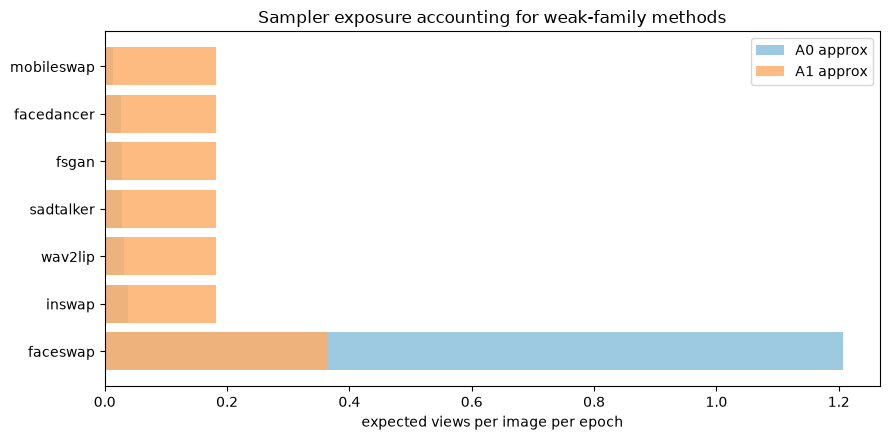

Existing balanced-training report summary:


,experiment_id,timestamp,model,dataset.train_samples,dataset.val_samples,dataset.test_samples,dataset.balance_ratio,training_hyperparameters.epochs,training_hyperparameters.batch_size,training_hyperparameters.base_lr,...,test_metrics.specificity_real,test_metrics.f1_score,test_metrics.roc_auc,test_metrics.pr_auc,test_metrics.brier_score,test_metrics.optimal_threshold,test_metrics.accuracy_optimal_tau,artifacts.best_checkpoint,artifacts.run_dir,artifacts.plots
0,EXP-02-BALANCED-TRAINING,2026-08-22 12:38:12,DINOv3 ViT-Small/16 (28.7M parameters),50000,5000,4134,1.00 : 1 (Real:Fake),5,32,0.00001,...,0.922593,0.925712,0.972717,0.975974,0.0574,0.691406,0.92985,/workspace/hoangtuan/deepfake-ViT/experiments/...,/workspace/hoangtuan/deepfake-ViT/experiments/...,[/workspace/hoangtuan/deepfake-ViT/experiments...


In [18]:
from pathlib import Path
import json
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x): print(x.to_string() if hasattr(x, "to_string") else x)

WEAK8 = {"faceswap", "deepfake_faceswap", "wav2lip", "sadtalker", "fsgan", "facedancer", "inswap", "mobileswap"}
PROJECT_ROOT = Path(os.getcwd()).resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path("/Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT")

protocol_cfg = PROJECT_ROOT / "data/protocol/protocol_config.json"
metadata_path = PROJECT_ROOT / "data/protocol/protocol_metadata.json"
preproc_path = PROJECT_ROOT / "src/data/preprocessing.py"
print(f"Project root: {PROJECT_ROOT}")
print(f"Protocol config exists: {protocol_cfg.exists()}")
print(f"Canonical preprocessing exists: {preproc_path.exists()}")

cfg = json.loads(protocol_cfg.read_text()) if protocol_cfg.exists() else {}
meta = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}
print(json.dumps({"protocol": cfg.get("DATA_PROTOCOL"), "train_csv": cfg.get("train_csv"), "val_csv": cfg.get("val_csv"), "test_csv": cfg.get("test_csv")}, indent=2))

def read(path):
    return pd.read_csv(path) if path and Path(path).exists() else pd.DataFrame()

def detailed(path):
    p = Path(path)
    return p.with_name(p.stem + "_detailed" + p.suffix)

train = read(detailed(cfg.get("train_csv", ""))) if cfg else pd.DataFrame()
val = read(detailed(cfg.get("val_csv", ""))) if cfg else pd.DataFrame()
test = read(detailed(cfg.get("test_csv", ""))) if cfg else pd.DataFrame()
rows = []
for name, df in [("train", train), ("val", val), ("test", test)]:
    if df.empty: continue
    rows.append({
        "split": name, "rows": len(df),
        "real": int((df.label == 0).sum()), "fake": int((df.label == 1).sum()),
        "fake_to_real": round((df.label == 1).sum() / max(1, (df.label == 0).sum()), 2),
        "fake_methods": df.loc[df.label == 1, "method"].nunique(),
        "domains": df.domain.nunique() if "domain" in df else np.nan,
    })
display(pd.DataFrame(rows))

print("Pipeline target input: 256x256 from src/data/preprocessing.py and training transforms. This is model input, not original image dimension.")
qpath = PROJECT_ROOT / "experiments/results/data_quality/sample_quality.csv"
if qpath.exists() and not train.empty:
    q = pd.read_csv(qpath)
    q["path"] = q["path"].astype(str)
    t = train.copy(); t["path"] = t["path"].astype(str)
    tq = t.merge(q[[c for c in ["path", "width", "height"] if c in q.columns]], on="path", how="left")
    if {"width", "height"}.issubset(tq.columns):
        tq["size"] = tq["width"].astype("Int64").astype(str) + "x" + tq["height"].astype("Int64").astype(str)
        display(tq.groupby(["label", "method", "size"]).size().reset_index(name="n").sort_values("n", ascending=False).head(20))

# Exposure simulation: not a new sampler, only a transparent accounting view for any existing sampler decision.
if not train.empty and {"label", "method"}.issubset(train.columns):
    real_n = int((train.label == 0).sum())
    fake_counts = train.loc[train.label == 1, "method"].value_counts()
    epoch_slots = 2 * real_n if real_n else len(train)
    rows = []
    other_methods = [m for m in fake_counts.index if m not in WEAK8]
    for method, pool in fake_counts.items():
        # A0 approximation from Session 2 report: faceswap-heavy plus equal other-method allocation.
        if method == "faceswap":
            a0_slots = 0.35 * epoch_slots
        else:
            a0_slots = (0.30 * epoch_slots / max(1, len(fake_counts) - 1))
        # A1 approximation from Session 2 report: real .35, weak8 .45 by pool with faceswap double weight, other .20 equal by method.
        if method in WEAK8:
            weights = fake_counts[fake_counts.index.isin(WEAK8)].astype(float).copy()
            if "faceswap" in weights.index:
                weights.loc["faceswap"] *= 2.0
            a1_slots = 0.45 * epoch_slots * (weights.get(method, 0.0) / max(weights.sum(), 1.0))
        else:
            a1_slots = 0.20 * epoch_slots / max(1, len(other_methods))
        rows.append({"method": method, "pool": int(pool), "weak8": method in WEAK8,
                     "A0_exposure_x": a0_slots / pool, "A1_exposure_x": a1_slots / pool,
                     "A1_vs_A0": (a1_slots / pool) / max(a0_slots / pool, 1e-12)})
    exposure = pd.DataFrame(rows).sort_values(["weak8", "A1_vs_A0"], ascending=[False, False])
    display(exposure[exposure.weak8].sort_values("method"))
    display(exposure.sort_values("A0_exposure_x").head(12))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    plot_df = exposure[exposure.weak8].sort_values("A1_vs_A0")
    if not plot_df.empty:
        ax.barh(plot_df.method, plot_df.A0_exposure_x, label="A0 approx", color="#9ecae1")
        ax.barh(plot_df.method, plot_df.A1_exposure_x, label="A1 approx", color="#fdae6b", alpha=0.85)
        ax.set_xlabel("expected views per image per epoch")
        ax.set_title("Sampler exposure accounting for weak-family methods")
        ax.legend()
        plt.tight_layout(); plt.show()

train_report = PROJECT_ROOT / "experiments/results/training_balanced_report.json"
if train_report.exists():
    rep = json.loads(train_report.read_text())
    print("Existing balanced-training report summary:")
    display(pd.json_normalize(rep, sep="."))
else:
    print("No local balanced-training report found.")

---
# SESSION-2 EDA ADDENDUM - Distribution, Sampling Exposure and Balanced Evaluation

Central distinction preserved throughout:

| Concept | Mutable? |
|---|---|
| **Dataset split** (train/val/test membership) | **NO** |
| **Training sampling strategy** (which images batches draw) | YES |

Balancing changes how TRAIN batches are drawn. **Validation and test keep
their natural distribution.** Never rebalance an evaluation set.

### Provenance convention used in this addendum

Every figure below is tagged:

* **MEASURED** - computed from an artifact present in this repository.
* **REFERENCE** - quoted from `session2_finetune_data_eda.pdf` because the
  underlying raw data is *not* in this repository. Never presented as measured.

The Session-2 **training** corpus (`finetune_plus_train.csv`, ~123.6k images)
and the 50k test suite are not committed here. The Session-2 **evaluation**
artifacts are, under `experiments/results/coursework_vs/`, so all
evaluation-side findings are reproduced from real paired predictions.

In [19]:
# --- Session-2 addendum bootstrap (shared implementation, no duplication) ---
import sys
from pathlib import Path

_ROOT = Path.cwd()
if _ROOT.name == "notebooks":
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from src.data import session2_eda as S2
from src.data import protocol as P
from src.data import loader

pd.set_option("display.width", 200)

# ---- Shared consistency banner: identical in all five notebooks. ----
# Values come from src.data.session2_eda (REFERENCE + measured .npz preds).
# If any notebook ever printed different values here, the notebooks would be
# describing different data. They cannot, because they all read one module.
print(S2.consistency_banner())
print()
print(P.describe())
print()
print(loader.describe())
print()
print("KNOWN LIMITATIONS OF THE ACTIVE PROTOCOL")
for _lim in P.KNOWN_LIMITATIONS:
    print(f"  - {_lim}")
print()

# Be explicit about which reference findings can and cannot be measured here.
print(S2.describe())

Session 2 Analysis Consistency
Session-2 dataset identity : finetune_plus (Session-2 finetune corpus / session2_finetune_data_eda.pdf)
  total images (train)   : 123,582  (29,557 real / 94,025 fake)  [REFERENCE]
  fake methods           : 42  | real sources: 9  [REFERENCE]
  canonical test composition [REFERENCE]:
    val=6,302  test_full=50,084  test_balanced=21,446 (1:1)
  balanced test MEASURED : n=21,446  real=10,723  fake=10,723  (1:1.00)
  analysis/prediction artifacts : experiments/results/coursework_vs/*.npz  [AVAILABLE]

Protocol distinction (never mix corpora):
  - Session-2 analysis uses the Session-2 balanced test / .npz preds above.
  - Local active protocol is identity_clean_v1 (separate corpus; ~4.5k imbalanced test).

CANONICAL DATASET PROTOCOL
  name              : identity_clean_v1
  strategy          : identity-disjoint
  seed              : 42
  dataset root      : /Users/pickapu/Documents/PyCharmMiscProject/deepfake-ViT/test_data_v3
  protocol dir      : /Users/pic

## D1. Training distribution vs evaluation distribution

In [20]:
rows = []
for s in P.SPLITS:
    c = loader.class_counts(s)
    rows.append({"split": s, "source": "local identity_clean_v1 (MEASURED)",
                 "total": c["total"], "real": c["real"], "fake": c["fake"],
                 "real:fake": f"1:{c['fake']/max(1,c['real']):.2f}"})
ref = S2.REFERENCE
for nm, tot, re_, fa in [("train", ref["train_total"], ref["train_real"], ref["train_fake"]),
                         ("val", ref["val_total"], 1449, 4853),
                         ("test (full)", ref["test_full"], 25042, 25042),
                         ("test (balanced)", ref["test_balanced"], 10723, 10723)]:
    rows.append({"split": nm, "source": "Session-2 (REFERENCE)", "total": tot,
                 "real": re_, "fake": fa, "real:fake": f"1:{fa/max(1,re_):.2f}"})
dist = pd.DataFrame(rows); display(dist)

comp = S2.test_composition()
print(f"Session-2 balanced test VERIFIED locally from predictions: "
      f"n={comp['n_total']:,} real={comp['n_real']:,} fake={comp['n_fake']:,} "
      f"(1:{comp['real_fake_ratio']:.2f})")
print("  -> the 21,446 / 1:1 figure is MEASURED here, not merely quoted.")

,split,source,total,real,fake,real:fake
0,train,local identity_clean_v1 (MEASURED),20991,826,20165,1:24.41
1,val,local identity_clean_v1 (MEASURED),4498,180,4318,1:23.99
2,test,local identity_clean_v1 (MEASURED),4499,171,4328,1:25.31
3,train,Session-2 (REFERENCE),123582,29557,94025,1:3.18
4,val,Session-2 (REFERENCE),6302,1449,4853,1:3.35
5,test (full),Session-2 (REFERENCE),50084,25042,25042,1:1.00
6,test (balanced),Session-2 (REFERENCE),21446,10723,10723,1:1.00


Session-2 balanced test VERIFIED locally from predictions: n=21,446 real=10,723 fake=10,723 (1:1.00)
  -> the 21,446 / 1:1 figure is MEASURED here, not merely quoted.


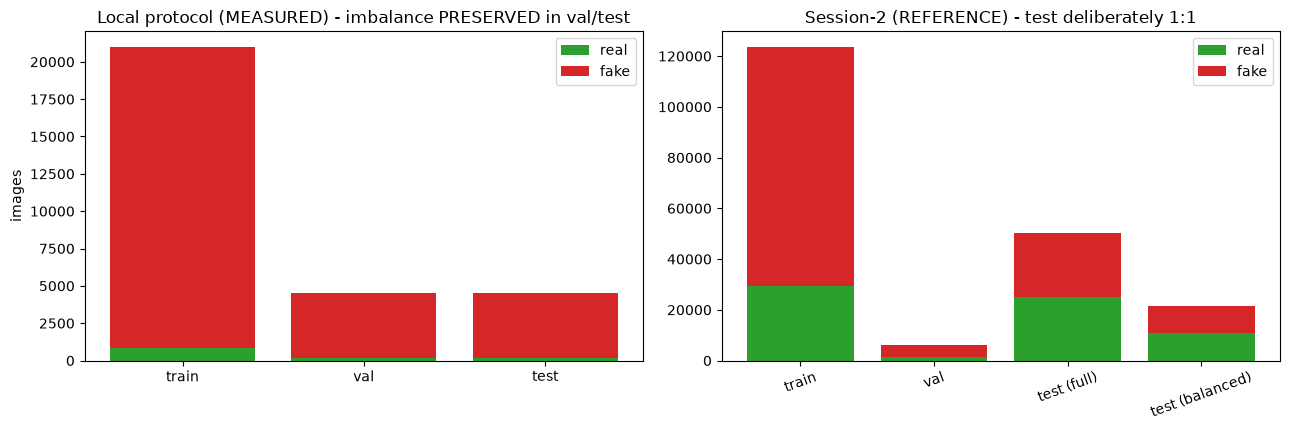

WHY A BALANCED TEST: with real at ~4%, predicting 'fake' always yields
~96% accuracy while real detection is broken. A 1:1 test removes that
escape hatch and measures both directions honestly.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
loc = dist[dist["source"].str.startswith("local")]
axes[0].bar(loc["split"], loc["real"], label="real", color="#2ca02c")
axes[0].bar(loc["split"], loc["fake"], bottom=loc["real"], label="fake", color="#d62728")
axes[0].set_title("Local protocol (MEASURED) - imbalance PRESERVED in val/test")
axes[0].set_ylabel("images"); axes[0].legend()

s2 = dist[dist["source"].str.startswith("Session-2")]
axes[1].bar(s2["split"], s2["real"], label="real", color="#2ca02c")
axes[1].bar(s2["split"], s2["fake"], bottom=s2["real"], label="fake", color="#d62728")
axes[1].set_title("Session-2 (REFERENCE) - test deliberately 1:1")
axes[1].tick_params(axis="x", rotation=20); axes[1].legend()
plt.tight_layout(); plt.show()

print("WHY A BALANCED TEST: with real at ~4%, predicting 'fake' always yields")
print("~96% accuracy while real detection is broken. A 1:1 test removes that")
print("escape hatch and measures both directions honestly.")

## D2. Exposure: what the sampler actually shows the model

,method,pool,A0_exposure,A1_exposure,change_x,in_weak_family
0,faceswap,11953,1.731,1.031,0.596,True
1,deepfake_faceswap,7672,0.056,0.516,9.146,True
2,facedancer,4386,0.099,0.516,5.230,True
3,sadtalker,4383,0.099,0.516,5.225,True
4,sfhq_studio,4156,0.104,0.217,2.089,False
5,simswap,3407,0.127,0.217,1.712,False
6,blendface,3402,0.127,0.217,1.710,False
7,fsgan,3401,0.127,0.516,4.055,True
8,inswap,2932,0.148,0.516,3.496,True
9,wav2lip,2927,0.148,0.516,3.489,True


Recomputed with the project's own allocation rules; validated against
the reference in notebook 00 section A6.


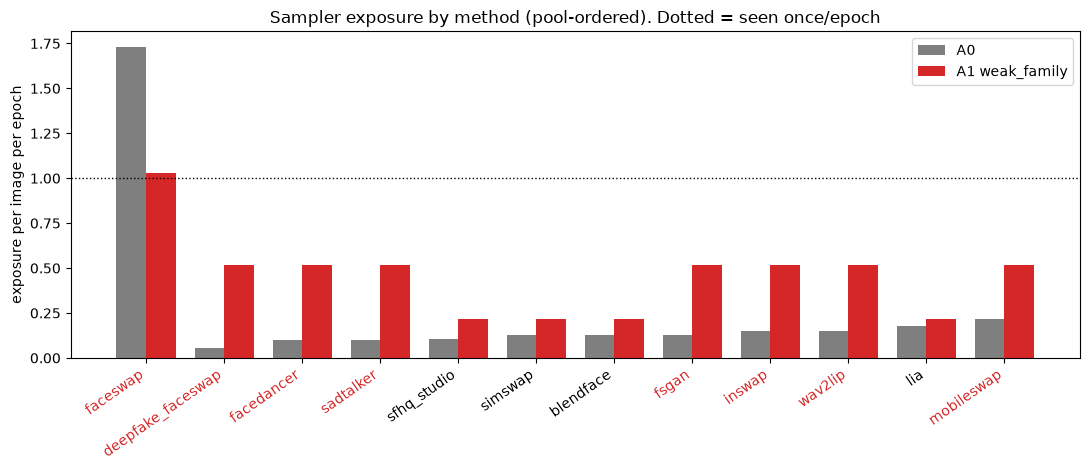

Red x-labels = the 8 boosted weak-family methods.


In [22]:
exp = S2.exposure_table()
display(exp.round(3))
print("Recomputed with the project's own allocation rules; validated against")
print("the reference in notebook 00 section A6.")

fig, ax = plt.subplots(figsize=(11, 4.8))
e = exp[exp["method"] != "real"].sort_values("pool", ascending=False)
x = np.arange(len(e)); bw = 0.38
ax.bar(x - bw/2, e["A0_exposure"], bw, label="A0", color="#7f7f7f")
ax.bar(x + bw/2, e["A1_exposure"], bw, label="A1 weak_family", color="#d62728")
ax.axhline(1.0, ls=":", c="k", lw=1)
ax.set_xticks(x); ax.set_xticklabels(e["method"], rotation=35, ha="right")
ax.set_ylabel("exposure per image per epoch")
ax.set_title("Sampler exposure by method (pool-ordered). Dotted = seen once/epoch")
for i, w in enumerate(e["in_weak_family"]):
    if w:
        ax.get_xticklabels()[i].set_color("#d62728")
ax.legend(); plt.tight_layout(); plt.show()
print("Red x-labels = the 8 boosted weak-family methods.")

## D3. Balancing strategies available, and their blast radius

In [23]:
display(pd.DataFrame([
    {"strategy": "class-weighted loss", "changes": "loss term",
     "train rows changed": "no", "val/test touched": "NO",
     "status": "used by the local baseline"},
    {"strategy": "WeightedRandomSampler", "changes": "batch sampling",
     "train rows changed": "no", "val/test touched": "NO",
     "status": "available in src/data/loader.py"},
    {"strategy": "A0 faceswap-focused sampler", "changes": "bucket allocation",
     "train rows changed": "no", "val/test touched": "NO",
     "status": "Session-2 baseline"},
    {"strategy": "A1 weak-family boosted sampler", "changes": "bucket allocation",
     "train rows changed": "no", "val/test touched": "NO",
     "status": "Session-2 improvement (validated)"},
    {"strategy": "physically duplicating rows", "changes": "dataset itself",
     "train rows changed": "YES", "val/test touched": "NO",
     "status": "NOT used - distorts the corpus"},
]))
print("Every strategy in use alters sampling or loss only. None edits val/test.")

,strategy,changes,train rows changed,val/test touched,status
0,class-weighted loss,loss term,no,NO,used by the local baseline
1,WeightedRandomSampler,batch sampling,no,NO,available in src/data/loader.py
2,A0 faceswap-focused sampler,bucket allocation,no,NO,Session-2 baseline
3,A1 weak-family boosted sampler,bucket allocation,no,NO,Session-2 improvement (validated)
4,physically duplicating rows,dataset itself,YES,NO,NOT used - distorts the corpus


Every strategy in use alters sampling or loss only. None edits val/test.


In [24]:
# Demonstrate on the local protocol that balancing is TRAIN-only, and that the
# guard rails refuse to touch evaluation splits.
sampler = loader.weighted_random_sampler("train")
train_df = loader.load_split("train", detailed=False)
idx = list(iter(sampler))[:4000]
drawn = train_df.iloc[idx]["label"].value_counts(normalize=True)
print(f"natural TRAIN split      : real={(train_df['label']==0).mean():.1%} "
      f"fake={(train_df['label']==1).mean():.1%}")
print(f"sampled TRAIN batches    : real={drawn.get(0,0):.1%} fake={drawn.get(1,0):.1%}")
print(f"sampler length           : {len(sampler):,} (= train size, epoch preserved)")

for split in ["val", "test"]:
    try:
        loader.weighted_random_sampler(split)
        print(f"{split}: ERROR - balancing was permitted!")
    except ValueError as e:
        print(f"{split}: correctly blocked -> {e}")
for split in ["val", "test"]:
    c = loader.class_counts(split)
    print(f"  {split} unchanged: real={c['real']} fake={c['fake']}")

natural TRAIN split      : real=3.9% fake=96.1%
sampled TRAIN batches    : real=49.1% fake=50.8%
sampler length           : 20,991 (= train size, epoch preserved)
val: correctly blocked -> Balancing may only be applied to the train split. Validation and test populations are immutable.
test: correctly blocked -> Balancing may only be applied to the train split. Validation and test populations are immutable.
  val unchanged: real=180 fake=4318
  test unchanged: real=171 fake=4328


## D4. Does exposure relate to measured performance?

,pool,A0_exposure,A1_exposure,exposure_gain_x,ViT-Plus A0 (old sampler),ViT-Plus A1 (weak_family),delta_det,in_weak_family
method,,,,,,,,
deepfake_faceswap,7672,0.0564,0.5156,9.1460,0.7700,0.9733,0.2033,True
wav2lip,2927,0.1478,0.5155,3.4887,0.9133,0.9833,0.0700,True
sadtalker,4383,0.0987,0.5156,5.2250,0.9433,0.9833,0.0400,True
fsgan,3401,0.1272,0.5157,4.0551,0.9400,0.9700,0.0300,True
inswap,2932,0.1475,0.5157,3.4957,0.9633,0.9933,0.0300,True
faceswap,11953,1.7309,1.0313,0.5958,0.9367,0.9600,0.0233,True
mobileswap,1980,0.2185,0.5157,2.3605,0.9667,0.9867,0.0200,True
facedancer,4386,0.0986,0.5157,5.2296,0.9567,0.9733,0.0167,True
blendface,3402,0.1271,0.2174,1.7097,0.9700,0.9833,0.0133,False


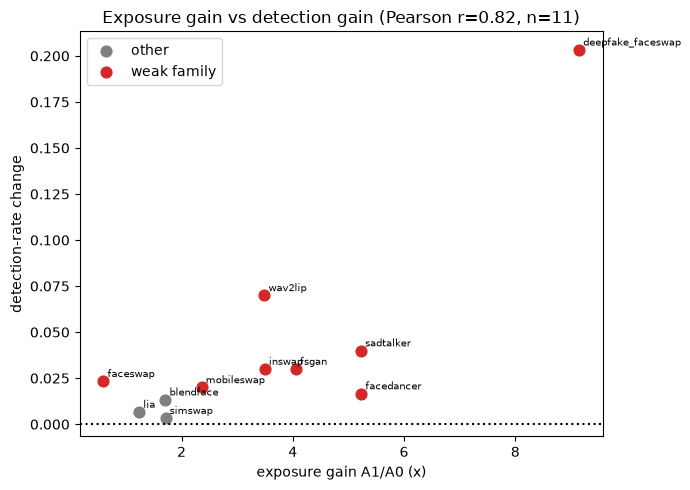

Pearson r = 0.822 across 11 methods with known pools.
ASSOCIATION ONLY - n is small and pools come from the reference.
It is consistent with exposure driving the weak-family gains.


In [25]:
if S2.availability().eval_preds:
    pm = S2.per_method_detection([S2.A0, S2.A1]).pivot(
        index="method", columns="model", values="det_rate")
    j = exp.set_index("method").join(pm, how="inner")
    j["delta_det"] = j[S2.A1] - j[S2.A0]
    j["exposure_gain_x"] = j["change_x"]
    cols = ["pool", "A0_exposure", "A1_exposure", "exposure_gain_x",
            S2.A0, S2.A1, "delta_det", "in_weak_family"]
    display(j[cols].sort_values("delta_det", ascending=False).round(4))

    sub = j.dropna(subset=["delta_det", "exposure_gain_x"])
    if len(sub) > 2:
        r = np.corrcoef(sub["exposure_gain_x"], sub["delta_det"])[0, 1]
        fig, ax = plt.subplots(figsize=(7, 5))
        for wk, g in sub.groupby("in_weak_family"):
            ax.scatter(g["exposure_gain_x"], g["delta_det"], s=60,
                       label="weak family" if wk else "other",
                       color="#d62728" if wk else "#7f7f7f")
        for m, r_ in sub.iterrows():
            ax.annotate(m, (r_["exposure_gain_x"], r_["delta_det"]), fontsize=7,
                        xytext=(3, 3), textcoords="offset points")
        ax.axhline(0, ls=":", c="k")
        ax.set_xlabel("exposure gain A1/A0 (x)"); ax.set_ylabel("detection-rate change")
        ax.set_title(f"Exposure gain vs detection gain (Pearson r={r:.2f}, n={len(sub)})")
        ax.legend(); plt.tight_layout(); plt.show()
        print(f"Pearson r = {r:.3f} across {len(sub)} methods with known pools.")
        print("ASSOCIATION ONLY - n is small and pools come from the reference.")
        print("It is consistent with exposure driving the weak-family gains.")
else:
    print("prediction artifacts unavailable - correlation not computed")

## D5. Summary

1. **Split membership is fixed.** Only loss weighting and batch sampling changed.
2. **Evaluation distribution is never rebalanced.** The local protocol keeps its
   ~24.5:1 imbalance in val/test; Session-2 uses a *separately constructed* 1:1
   test suite, verified locally at 21,446 images.
3. **A0 starved the long tail** (~0.06x/epoch for `deepfake_faceswap`);
   **A1 lifts all 8 weak methods to ~0.52x** - recomputed, matching the reference.
4. **Measured detection gains land on the boosted methods**, with no significant
   regression elsewhere (see `02_error_analysis`).
5. Exposure gain and detection gain are **positively associated**; with a handful
   of methods and reference-sourced pools this is supporting evidence, not proof.